<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_second_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_excel('/content/drive/MyDrive/Dr Kalyani thesis training Dataset KH KV AL ACD LT.xlsx')


In [4]:
df.shape

(503, 8)

In [5]:
df.columns

Index(['AGE ', 'SEX', 'KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT'], dtype='object')

In [7]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)

# Calculate correlation on the numeric DataFrame
correlation_matrix = numeric_df.corr()

# Display the correlation matrix (optional)
print(correlation_matrix)

          AGE         KH        KV      AXIS        AL       ACD        LT
AGE   1.000000 -0.359789 -0.337968 -0.082054  0.375333  0.138615 -0.196134
KH   -0.359789  1.000000  0.925555  0.037769 -0.686417 -0.399329  0.380340
KV   -0.337968  0.925555  1.000000  0.057635 -0.691322 -0.408852  0.383358
AXIS -0.082054  0.037769  0.057635  1.000000 -0.089184 -0.093266  0.031591
AL    0.375333 -0.686417 -0.691322 -0.089184  1.000000  0.461342 -0.436640
ACD   0.138615 -0.399329 -0.408852 -0.093266  0.461342  1.000000 -0.479859
LT   -0.196134  0.380340  0.383358  0.031591 -0.436640 -0.479859  1.000000


In [10]:
# prompt: X as AGE, and ACD. y as AL

X = df[['AGE ']]
y = df['AL']

Mean Squared Error: 0.981203913496392
Root Mean Squared Error: 0.9905573751663213
R-squared: 0.22191591056133864


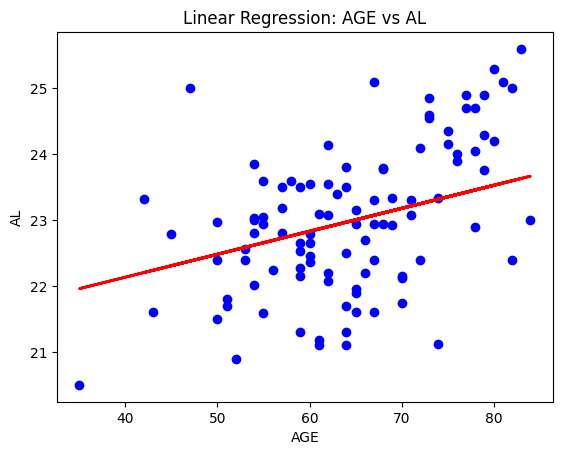

In [29]:
# prompt: Linear regression

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

# Plot the results
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('Linear Regression: AGE vs AL')
plt.show()



Polynomial Regression (Degree 2):
Mean Squared Error: 0.9595608624432497
Root Mean Squared Error: 0.979571775033994
R-squared: 0.23907861592739355


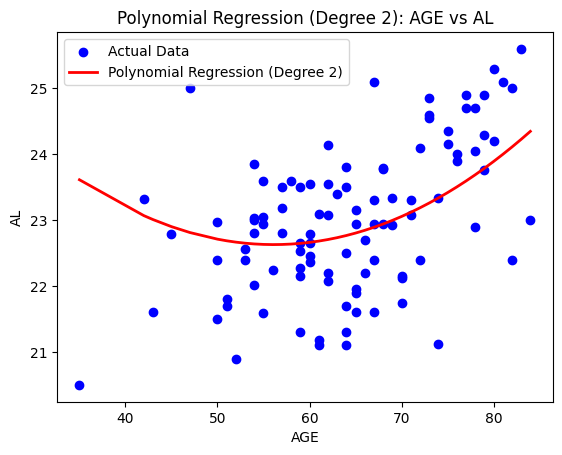

In [30]:
# prompt: Polynomials

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create polynomial features
degree = 2  # You can change the degree of the polynomial
poly_features = PolynomialFeatures(degree=degree, include_bias=False)

# Create a pipeline that first transforms the features and then applies Linear Regression
polynomial_regressor = make_pipeline(poly_features, LinearRegression())

# Train the polynomial regression model
polynomial_regressor.fit(X_train, y_train)

# Make predictions on the test set using the polynomial model
y_pred_poly = polynomial_regressor.predict(X_test)

# Evaluate the polynomial model
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"\nPolynomial Regression (Degree {degree}):")
print(f"Mean Squared Error: {mse_poly}")
print(f"Root Mean Squared Error: {rmse_poly}")
print(f"R-squared: {r2_poly}")

# Plot the results for polynomial regression
# Sort the test data for smoother plotting of the polynomial curve
X_test_sorted, y_pred_poly_sorted = zip(*sorted(zip(X_test['AGE '], y_pred_poly)))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test_sorted, y_pred_poly_sorted, color='red', linewidth=2, label=f'Polynomial Regression (Degree {degree})')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title(f'Polynomial Regression (Degree {degree}): AGE vs AL')
plt.legend()
plt.show()



Random Forest Regression:
Mean Squared Error: 1.1010716441471153
Root Mean Squared Error: 1.0493196101031923
R-squared: 0.12686209679891547


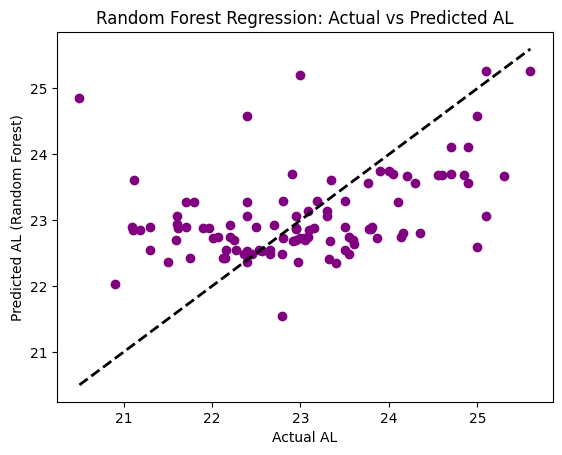

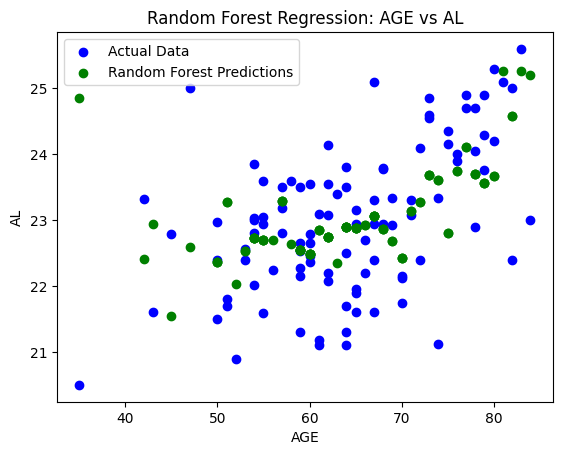

In [31]:
# prompt: Random forest

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
# You can adjust the number of trees (n_estimators) and other parameters
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regression:")
print(f"Mean Squared Error: {mse_rf}")
print(f"Root Mean Squared Error: {rmse_rf}")
print(f"R-squared: {r2_rf}")

# Plotting Random Forest results is a bit different as it doesn't produce a simple line.
# We can scatter plot the actual vs predicted values or sort and plot the predictions.
# For simplicity, let's plot actual vs predicted:
plt.scatter(y_test, y_pred_rf, color='purple')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (Random Forest)')
plt.title('Random Forest Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

# Alternatively, to visualize the prediction against the feature (like the previous plots)
# We can sort the test data by AGE and plot the corresponding predictions.
X_test_sorted_rf, y_pred_rf_sorted = zip(*sorted(zip(X_test['AGE '], y_pred_rf)))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_rf, y_pred_rf_sorted, color='green', label='Random Forest Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('Random Forest Regression: AGE vs AL')
plt.legend()
plt.show()


Support Vector Regression:
Mean Squared Error: 1.0665258047189847
Root Mean Squared Error: 1.0327273622399016
R-squared: 0.15425657377317592


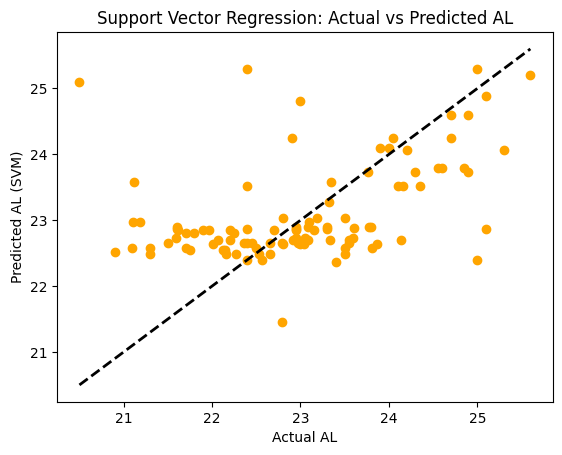

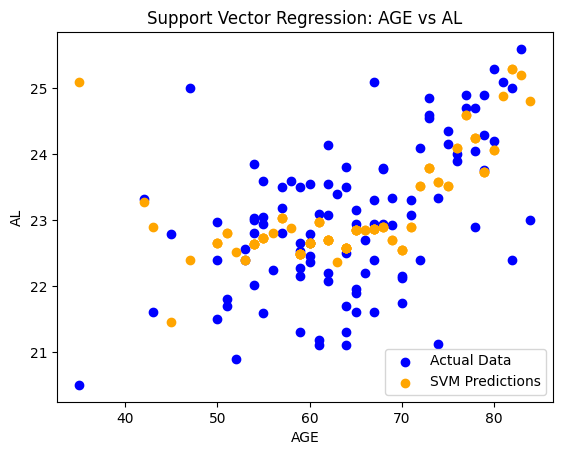

In [33]:
# prompt: Svm

import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVR

# Initialize the Support Vector Regressor model
# You can experiment with different kernels ('linear', 'poly', 'rbf') and parameters (C, epsilon, gamma)
svm_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)

# Train the SVM model
# Note: SVR can be sensitive to feature scaling. It's often recommended to scale your features before training SVM.
# For this example, we'll use the unscaled data, but consider adding scaling for better performance in practice.
# from sklearn.preprocessing import StandardScaler
# scaler_X = StandardScaler()
# scaler_y = StandardScaler()
# X_train_scaled = scaler_X.fit_transform(X_train)
# y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
# svm_model.fit(X_train_scaled, y_train_scaled.ravel())

svm_model.fit(X_train, y_train)


# Make predictions on the test set using the SVM model
# If you scaled the training data, you would also need to scale the test data and inverse transform the predictions
# X_test_scaled = scaler_X.transform(X_test)
# y_pred_svm_scaled = svm_model.predict(X_test_scaled)
# y_pred_svm = scaler_y.inverse_transform(y_pred_svm_scaled.reshape(-1, 1))

y_pred_svm = svm_model.predict(X_test)


# Evaluate the SVM model
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("\nSupport Vector Regression:")
print(f"Mean Squared Error: {mse_svm}")
print(f"Root Mean Squared Error: {rmse_svm}")
print(f"R-squared: {r2_svm}")

# Plotting SVM results
# Similar to Random Forest, we can plot actual vs predicted or predictions against the feature.
plt.scatter(y_test, y_pred_svm, color='orange')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (SVM)')
plt.title('Support Vector Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

# To visualize the prediction against the feature (AGE)
# Sort the test data by AGE and plot the corresponding predictions.
X_test_sorted_svm, y_pred_svm_sorted = zip(*sorted(zip(X_test['AGE '], y_pred_svm)))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_svm, y_pred_svm_sorted, color='orange', label='SVM Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('Support Vector Regression: AGE vs AL')
plt.legend()
plt.show()



K-Nearest Neighbors Regression:
Mean Squared Error: 1.074925821782178
Root Mean Squared Error: 1.0367862951361664
R-squared: 0.14759545110745598


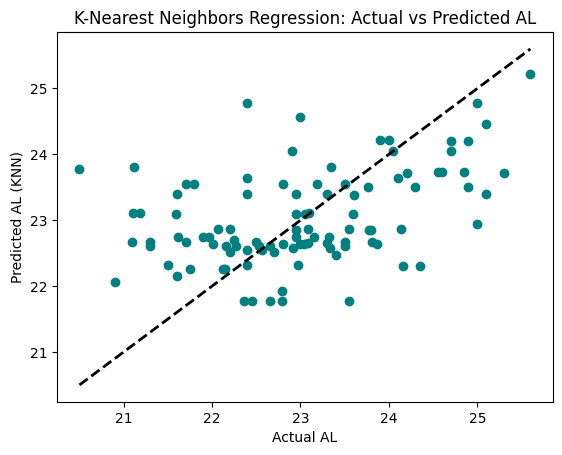

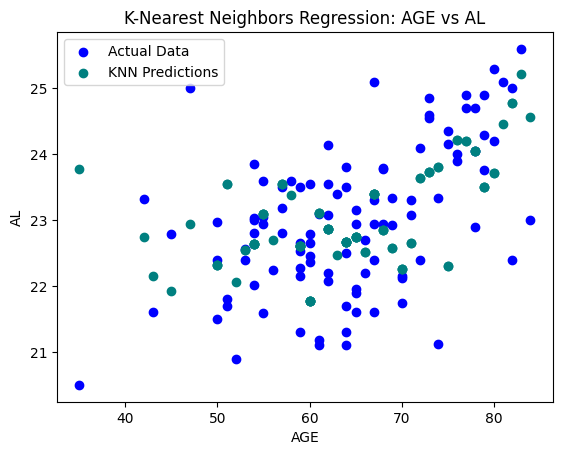

In [34]:
# prompt: Knn

import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

# Initialize the K-Nearest Neighbors Regressor model
# You can experiment with different values of k (n_neighbors) and other parameters
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train the KNN model
knn_model.fit(X_train, y_train)

# Make predictions on the test set using the KNN model
y_pred_knn = knn_model.predict(X_test)

# Evaluate the KNN model
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("\nK-Nearest Neighbors Regression:")
print(f"Mean Squared Error: {mse_knn}")
print(f"Root Mean Squared Error: {rmse_knn}")
print(f"R-squared: {r2_knn}")

# Plotting KNN results
# Similar to Random Forest and SVM, we can plot actual vs predicted or predictions against the feature.
plt.scatter(y_test, y_pred_knn, color='teal')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (KNN)')
plt.title('K-Nearest Neighbors Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

# To visualize the prediction against the feature (AGE)
# Sort the test data by AGE and plot the corresponding predictions.
X_test_sorted_knn, y_pred_knn_sorted = zip(*sorted(zip(X_test['AGE '], y_pred_knn)))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_knn, y_pred_knn_sorted, color='teal', label='KNN Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('K-Nearest Neighbors Regression: AGE vs AL')
plt.legend()
plt.show()


Decision Tree Regression:
Mean Squared Error: 1.1476184099440252
Root Mean Squared Error: 1.0712695318844951
R-squared: 0.08995101503167346


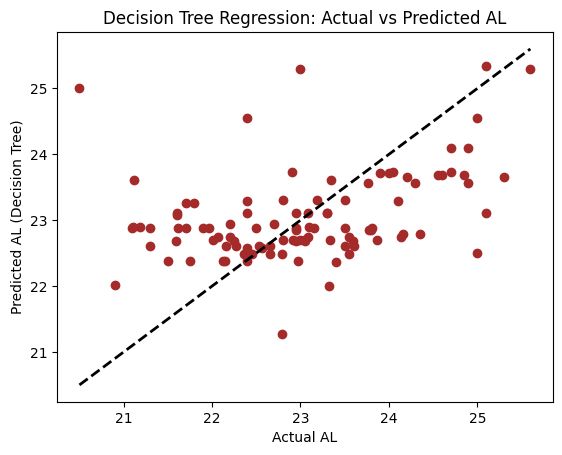

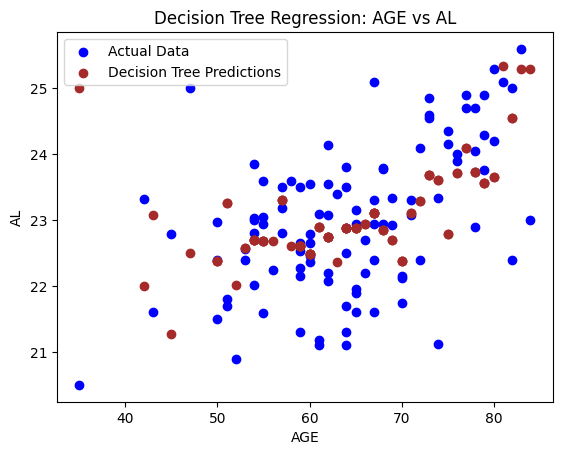

In [35]:
# prompt: Decision tree

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor model
# You can experiment with parameters like max_depth, min_samples_split, min_samples_leaf, etc.
dt_model = DecisionTreeRegressor(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Make predictions on the test set using the Decision Tree model
y_pred_dt = dt_model.predict(X_test)

# Evaluate the Decision Tree model
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree Regression:")
print(f"Mean Squared Error: {mse_dt}")
print(f"Root Mean Squared Error: {rmse_dt}")
print(f"R-squared: {r2_dt}")

# Plotting Decision Tree results
# Similar to other models, we can plot actual vs predicted or predictions against the feature.
plt.scatter(y_test, y_pred_dt, color='brown')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (Decision Tree)')
plt.title('Decision Tree Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

# To visualize the prediction against the feature (AGE)
# Sort the test data by AGE and plot the corresponding predictions.
X_test_sorted_dt, y_pred_dt_sorted = zip(*sorted(zip(X_test['AGE '], y_pred_dt)))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_dt, y_pred_dt_sorted, color='brown', label='Decision Tree Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('Decision Tree Regression: AGE vs AL')
plt.legend()
plt.show()


In [36]:
# prompt: Polynomials on all models

import numpy as np
def train_and_evaluate_polynomial(model, X_train, X_test, y_train, y_test, degree):
  """
    Trains and evaluates a model with polynomial features.

    Args:
      model: The base regression model (e.g., LinearRegression, RandomForestRegressor).
      X_train: Training features.
      X_test: Testing features.
      y_train: Training target.
      y_test: Testing target.
      degree: The degree of the polynomial features.

    Returns:
      A dictionary containing the evaluation metrics (MSE, RMSE, R2) and the trained model pipeline.
  """
  poly_features = PolynomialFeatures(degree=degree, include_bias=False)
  pipeline = make_pipeline(poly_features, model)

  pipeline.fit(X_train, y_train)
  y_pred = pipeline.predict(X_test)

  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  metrics = {
      "MSE": mse,
      "RMSE": rmse,
      "R2": r2
  }

  return metrics, pipeline

# Define models
linear_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
svm_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
knn_model = KNeighborsRegressor(n_neighbors=5)
dt_model = DecisionTreeRegressor(random_state=42)

models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model,
    "Decision Tree": dt_model
}

degree = 2 # Define the polynomial degree

results = {}
pipelines = {}

for name, model in models.items():
  print(f"\nTraining and evaluating {name} with Polynomial Features (Degree {degree}):")
  metrics, pipeline = train_and_evaluate_polynomial(model, X_train, X_test, y_train, y_test, degree)
  results[name] = metrics
  pipelines[name] = pipeline

  print(f"  Mean Squared Error: {metrics['MSE']}")
  print(f"  Root Mean Squared Error: {metrics['RMSE']}")
  print(f"  R-squared: {metrics['R2']}")

  # Optional: Plotting (similar to the original code, but you might want to generalize this)
  # For simplicity, let's just show the numerical results for all models with polynomials here.
  # You can add plotting logic for each model if needed, similar to the individual plots above.

print("\nSummary of Results with Polynomial Features:")
for name, metrics in results.items():
  print(f"{name}: R-squared = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.4f}")




Training and evaluating Linear Regression with Polynomial Features (Degree 2):
  Mean Squared Error: 0.9595608624432497
  Root Mean Squared Error: 0.979571775033994
  R-squared: 0.23907861592739355

Training and evaluating Random Forest with Polynomial Features (Degree 2):
  Mean Squared Error: 1.1010716441471153
  Root Mean Squared Error: 1.0493196101031923
  R-squared: 0.12686209679891536

Training and evaluating SVM with Polynomial Features (Degree 2):
  Mean Squared Error: 1.1619103742810561
  Root Mean Squared Error: 1.0779194655822188
  R-squared: 0.07861764191268261

Training and evaluating KNN with Polynomial Features (Degree 2):
  Mean Squared Error: 1.0821232871287123
  Root Mean Squared Error: 1.0402515499285316
  R-squared: 0.14188793894469998

Training and evaluating Decision Tree with Polynomial Features (Degree 2):
  Mean Squared Error: 1.1476184099440268
  Root Mean Squared Error: 1.0712695318844958
  R-squared: 0.08995101503167224

Summary of Results with Polynomial F


PCA Results:
   principal_component_1  principal_component_2     AL
0               0.441457              -1.258542  21.90
1              -0.582595              -1.200400  22.97
2              -0.367322              -1.037143  23.76
3              -0.467869               0.130710  22.77
4               0.138936              -0.092361  22.99

Explained variance ratio by component: [0.44997991 0.1675517 ]
Total explained variance by 2 components: 0.617531616872195


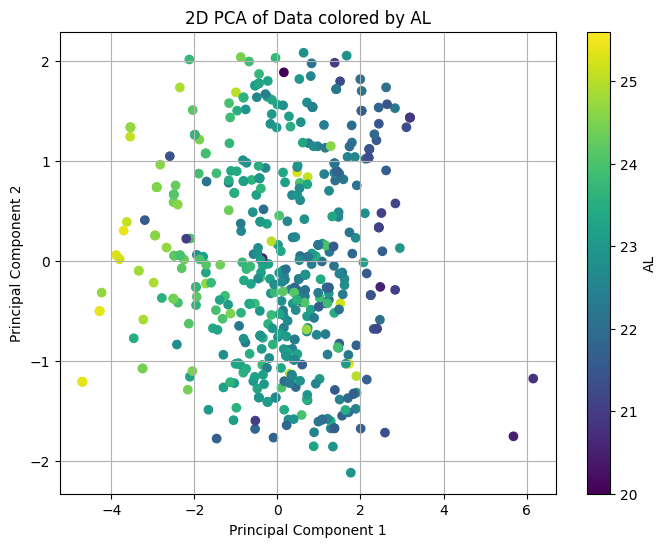


Linear Regression on PCA Components:
Mean Squared Error: 0.4942362839865586
Root Mean Squared Error: 0.7030194051280225
R-squared: 0.6080759730942072


In [37]:
# prompt: Pca

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming 'df' is already loaded and 'numeric_df' contains only numerical columns

# Select the features you want to apply PCA to.
# For example, let's use all numeric columns except the target variable 'AL'.
# Make sure 'AL' is a column in your numeric_df.
if 'AL' in numeric_df.columns:
  features_for_pca = numeric_df.drop('AL', axis=1)
else:
  features_for_pca = numeric_df.copy() # Use all numeric columns if 'AL' is not present

# Standardize the data before applying PCA
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_pca)

# Apply PCA
# You can choose the number of components. A common practice is to keep components
# that explain a certain percentage of variance (e.g., 95%) or a fixed number.
# Let's start with 2 components for visualization purposes.
n_components = 2
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(scaled_features)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data = principal_components, columns = [f'principal_component_{i+1}' for i in range(n_components)])

# Optionally, add the target variable back to the PCA DataFrame for analysis or plotting
if 'AL' in df.columns:
  pca_df['AL'] = df['AL']

print("\nPCA Results:")
print(pca_df.head())

# Explained variance ratio for each component
print(f"\nExplained variance ratio by component: {pca.explained_variance_ratio_}")
print(f"Total explained variance by {n_components} components: {np.sum(pca.explained_variance_ratio_)}")

# Plotting the first two principal components (if n_components is 2)
if n_components == 2 and 'AL' in pca_df.columns:
  plt.figure(figsize=(8, 6))
  plt.scatter(pca_df['principal_component_1'], pca_df['principal_component_2'], c=pca_df['AL'], cmap='viridis')
  plt.xlabel('Principal Component 1')
  plt.ylabel('Principal Component 2')
  plt.title('2D PCA of Data colored by AL')
  plt.colorbar(label='AL')
  plt.grid(True)
  plt.show()

# You can now use these principal components as features for your regression models
# Example: Split PCA data and use for Linear Regression
if 'AL' in pca_df.columns:
  X_pca = pca_df.drop('AL', axis=1)
  y_pca = pca_df['AL']

  X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y_pca, test_size=0.2, random_state=42)

  # Train a model on PCA components
  linear_model_pca = LinearRegression()
  linear_model_pca.fit(X_train_pca, y_train_pca)
  y_pred_pca = linear_model_pca.predict(X_test_pca)

  # Evaluate the model trained on PCA components
  mse_pca = mean_squared_error(y_test_pca, y_pred_pca)
  rmse_pca = np.sqrt(mse_pca)
  r2_pca = r2_score(y_test_pca, y_pred_pca)

  print("\nLinear Regression on PCA Components:")
  print(f"Mean Squared Error: {mse_pca}")
  print(f"Root Mean Squared Error: {rmse_pca}")
  print(f"R-squared: {r2_pca}")


In [38]:
# prompt: All models on pca components

import pandas as pd
import numpy as np
# Function to train and evaluate a model on PCA components
def train_and_evaluate_with_pca(model, X, y, n_components=2, test_size=0.2, random_state=42):
  """
    Trains and evaluates a model using Principal Component Analysis (PCA) as feature reduction.

    Args:
      model: The regression model.
      X: The feature DataFrame.
      y: The target Series.
      n_components: The number of PCA components to keep.
      test_size: The proportion of the dataset to include in the test split.
      random_state: Controls the shuffling applied to the data before applying the split.

    Returns:
      A dictionary containing the evaluation metrics (MSE, RMSE, R2).
  """
  # Ensure numerical data for PCA
  X_numeric = X.select_dtypes(include=np.number)

  # Standardize the data
  scaler = StandardScaler()
  scaled_X = scaler.fit_transform(X_numeric)

  # Apply PCA
  pca = PCA(n_components=n_components)
  principal_components = pca.fit_transform(scaled_X)

  # Create a DataFrame with principal components
  X_pca = pd.DataFrame(data = principal_components, columns = [f'principal_component_{i+1}' for i in range(n_components)])

  # Split data into training and testing sets
  X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=test_size, random_state=random_state)

  # Train the model on PCA components
  model.fit(X_train_pca, y_train_pca)
  y_pred_pca = model.predict(X_test_pca)

  # Evaluate the model
  mse_pca = mean_squared_error(y_test_pca, y_pred_pca)
  rmse_pca = np.sqrt(mse_pca)
  r2_pca = r2_score(y_test_pca, y_pred_pca)

  metrics = {
      "MSE": mse_pca,
      "RMSE": rmse_pca,
      "R2": r2_pca
  }

  return metrics

# Re-define models if needed (they were defined earlier in the preceding code)
# linear_model = LinearRegression()
# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# svm_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
# knn_model = KNeighborsRegressor(n_neighbors=5)
# dt_model = DecisionTreeRegressor(random_state=42)

models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model,
    "Decision Tree": dt_model
}

# Define features (using all numeric columns except the target 'AL' as in the PCA section)
features_for_pca = numeric_df.drop('AL', axis=1)
target = df['AL']

# Define the number of PCA components to use
n_components_to_use = 2 # You can adjust this based on explained variance or domain knowledge

print(f"\nTraining and evaluating models on {n_components_to_use} PCA Components:")

results_pca = {}

for name, model in models.items():
  print(f"\nEvaluating {name} on PCA Components:")
  # Create a fresh instance of the model for each evaluation
  if name == "Linear Regression":
    current_model = LinearRegression()
  elif name == "Random Forest":
    current_model = RandomForestRegressor(n_estimators=100, random_state=42)
  elif name == "SVM":
    current_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
  elif name == "KNN":
    current_model = KNeighborsRegressor(n_neighbors=5)
  elif name == "Decision Tree":
    current_model = DecisionTreeRegressor(random_state=42)
  else:
    current_model = model # Use the existing instance if not in the defined list

  metrics_pca = train_and_evaluate_with_pca(current_model, features_for_pca, target, n_components=n_components_to_use)
  results_pca[name] = metrics_pca

  print(f"  Mean Squared Error: {metrics_pca['MSE']:.4f}")
  print(f"  Root Mean Squared Error: {metrics_pca['RMSE']:.4f}")
  print(f"  R-squared: {metrics_pca['R2']:.4f}")

print("\nSummary of Results on PCA Components:")
for name, metrics in results_pca.items():
  print(f"{name}: R-squared = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.4f}")



Training and evaluating models on 2 PCA Components:

Evaluating Linear Regression on PCA Components:
  Mean Squared Error: 0.4942
  Root Mean Squared Error: 0.7030
  R-squared: 0.6081

Evaluating Random Forest on PCA Components:
  Mean Squared Error: 0.5581
  Root Mean Squared Error: 0.7471
  R-squared: 0.5574

Evaluating SVM on PCA Components:
  Mean Squared Error: 0.5013
  Root Mean Squared Error: 0.7080
  R-squared: 0.6025

Evaluating KNN on PCA Components:
  Mean Squared Error: 0.6324
  Root Mean Squared Error: 0.7953
  R-squared: 0.4985

Evaluating Decision Tree on PCA Components:
  Mean Squared Error: 0.9234
  Root Mean Squared Error: 0.9609
  R-squared: 0.2678

Summary of Results on PCA Components:
Linear Regression: R-squared = 0.6081, RMSE = 0.7030
Random Forest: R-squared = 0.5574, RMSE = 0.7471
SVM: R-squared = 0.6025, RMSE = 0.7080
KNN: R-squared = 0.4985, RMSE = 0.7953
Decision Tree: R-squared = 0.2678, RMSE = 0.9609


In [40]:
x1 = df[['AGE ', 'ACD']]
y1 = df['AL']


Multiple Linear Regression Results (AGE, ACD vs AL):
Mean Squared Error: 0.8833394866900975
Root Mean Squared Error: 0.9398614188751965
R-squared: 0.29952134239117423


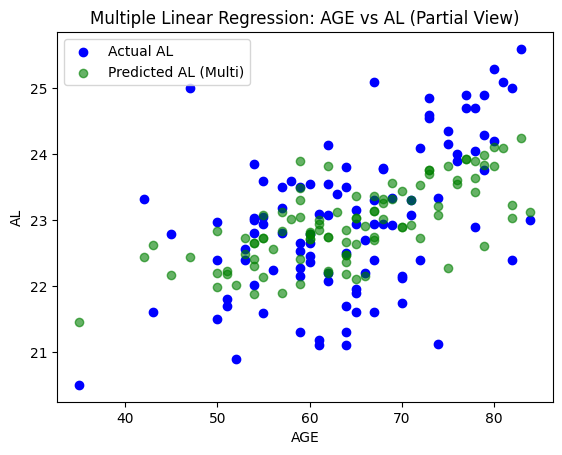

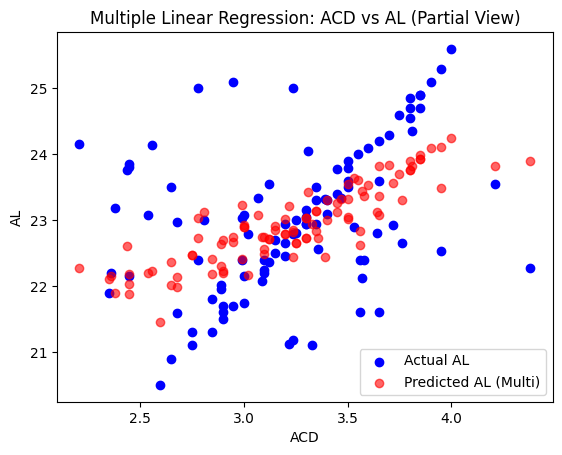

In [41]:
# prompt: Linear regression

import matplotlib.pyplot as plt
import numpy as np
# Split the data for multiple linear regression
X1_train, X1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)

# Initialize and train the multiple linear regression model
multi_model = LinearRegression()
multi_model.fit(X1_train, y1_train)

# Make predictions with the multiple linear regression model
y1_pred = multi_model.predict(X1_test)

# Evaluate the multiple linear regression model
mse1 = mean_squared_error(y1_test, y1_pred)
rmse1 = np.sqrt(mse1)
r21 = r2_score(y1_test, y1_pred)

print("\nMultiple Linear Regression Results (AGE, ACD vs AL):")
print(f"Mean Squared Error: {mse1}")
print(f"Root Mean Squared Error: {rmse1}")
print(f"R-squared: {r21}")

# Optional: Plotting for multiple linear regression is harder in 2D.
# You might visualize relationships between individual predictors and the target
# or use 3D plots if you have two predictors.

# Example: Scatter plot of AGE vs AL with the multiple regression predictions
# This does not fully represent the 3D plane but shows the relationship in 2D
plt.scatter(X1_test['AGE '], y1_test, color='blue', label='Actual AL')
plt.scatter(X1_test['AGE '], y1_pred, color='green', alpha=0.6, label='Predicted AL (Multi)')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('Multiple Linear Regression: AGE vs AL (Partial View)')
plt.legend()
plt.show()

# Example: Scatter plot of ACD vs AL with the multiple regression predictions
plt.scatter(X1_test['ACD'], y1_test, color='blue', label='Actual AL')
plt.scatter(X1_test['ACD'], y1_pred, color='red', alpha=0.6, label='Predicted AL (Multi)')
plt.xlabel('ACD')
plt.ylabel('AL')
plt.title('Multiple Linear Regression: ACD vs AL (Partial View)')
plt.legend()
plt.show()


Random Forest Regression:
Mean Squared Error: 0.5667987565564171
Root Mean Squared Error: 0.7528603831763344
R-squared: 0.5505347172753741


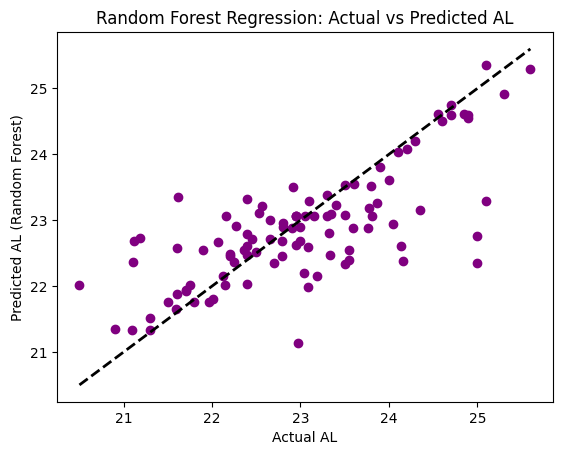

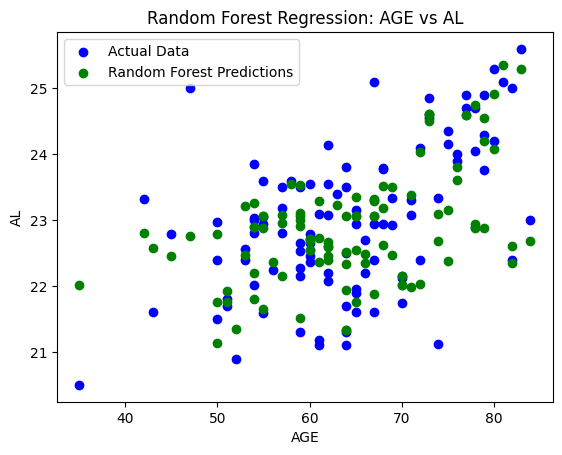

In [43]:
# prompt: Random forest

import matplotlib.pyplot as plt
import numpy as np
# Initialize the Random Forest Regressor model
# You can adjust the number of trees (n_estimators) and other parameters
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the Random Forest model
rf_model.fit(X1_train, y1_train)

# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X1_test)

# Evaluate the Random Forest model
mse_rf = mean_squared_error(y1_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y1_test, y_pred_rf)

print("\nRandom Forest Regression:")
print(f"Mean Squared Error: {mse_rf}")
print(f"Root Mean Squared Error: {rmse_rf}")
print(f"R-squared: {r2_rf}")

# Plotting Random Forest results is a bit different as it doesn't produce a simple line.
# We can scatter plot the actual vs predicted values or sort and plot the predictions.
# For simplicity, let's plot actual vs predicted:
plt.scatter(y1_test, y_pred_rf, color='purple') # Changed y_test to y1_test
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (Random Forest)')
plt.title('Random Forest Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'k--', lw=2)
plt.show()

# Alternatively, to visualize the prediction against the feature (like the previous plots)
# We can sort the test data by AGE and plot the corresponding predictions.
X_test_sorted_rf, y_pred_rf_sorted = zip(*sorted(zip(X1_test['AGE '], y_pred_rf)))

plt.scatter(X1_test['AGE '], y1_test, color='blue', label='Actual Data') # Select 'AGE ' column from X1_test
plt.scatter(X_test_sorted_rf, y_pred_rf_sorted, color='green', label='Random Forest Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('Random Forest Regression: AGE vs AL')
plt.legend()
plt.show()


Ordinary Least Squares (OLS) Regression Results:
                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     82.15
Date:                Wed, 02 Jul 2025   Prob (F-statistic):           2.84e-18
Time:                        17:15:13   Log-Likelihood:                -687.19
No. Observations:                 503   AIC:                             1378.
Df Residuals:                     501   BIC:                             1387.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

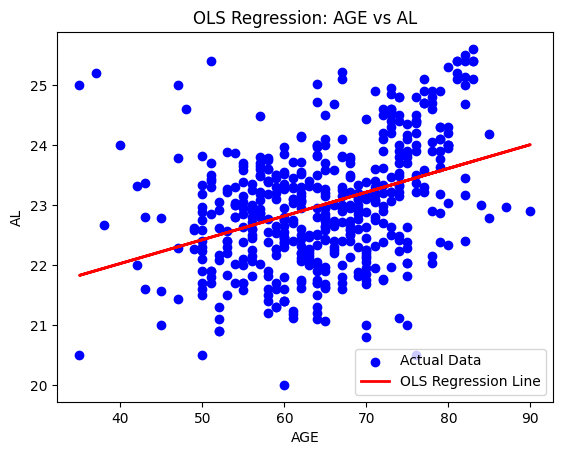


Ordinary Least Squares (OLS) Multiple Regression Results (AGE, ACD vs AL):
                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     113.2
Date:                Wed, 02 Jul 2025   Prob (F-statistic):           2.79e-41
Time:                        17:15:13   Log-Likelihood:                -631.43
No. Observations:                 503   AIC:                             1269.
Df Residuals:                     500   BIC:                             1282.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

In [44]:
# prompt: OLS

import matplotlib.pyplot as plt
# Ordinary Least Squares (OLS) using statsmodels
import statsmodels.api as sm

# Define the independent variable(s) (X) and the dependent variable (y)
# For OLS with statsmodels, you need to add a constant (intercept) to your independent variables.
X_ols = df[['AGE ']]  # Use the same feature as the original simple linear regression
X_ols = sm.add_constant(X_ols) # Add an intercept

y_ols = df['AL'] # Target variable

# Create and fit the OLS model
ols_model = sm.OLS(y_ols, X_ols)
ols_results = ols_model.fit()

# Print the summary of the OLS regression
print("\nOrdinary Least Squares (OLS) Regression Results:")
print(ols_results.summary())

# You can extract specific information from the results
# print(f"\nParameters (Coefficients): {ols_results.params}")
# print(f"R-squared: {ols_results.rsquared}")
# print(f"Adjusted R-squared: {ols_results.rsquared_adj}")
# print(f"P-values: {ols_results.pvalues}")

# Plotting the OLS results (similar to the simple linear regression plot)
# Get the predictions from the OLS model
y_pred_ols = ols_results.predict(X_ols)

plt.scatter(X_ols['AGE '], y_ols, color='blue', label='Actual Data')
plt.plot(X_ols['AGE '], y_pred_ols, color='red', linewidth=2, label='OLS Regression Line')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('OLS Regression: AGE vs AL')
plt.legend()
plt.show()


# OLS with multiple variables using statsmodels
X_multi_ols = df[['AGE ', 'ACD']] # Use the same features as the multiple linear regression
X_multi_ols = sm.add_constant(X_multi_ols) # Add an intercept

y_multi_ols = df['AL'] # Target variable

# Create and fit the OLS model for multiple regression
multi_ols_model = sm.OLS(y_multi_ols, X_multi_ols)
multi_ols_results = multi_ols_model.fit()

# Print the summary of the multiple OLS regression
print("\nOrdinary Least Squares (OLS) Multiple Regression Results (AGE, ACD vs AL):")
print(multi_ols_results.summary())

# Plotting for multiple OLS is similarly challenging in 2D as with scikit-learn's LinearRegression.
# The summary provides the key statistical insights.



K-Nearest Neighbors Regression:
Mean Squared Error: 0.8611512475247526
Root Mean Squared Error: 0.9279823530244272
R-squared: 0.3171163760327498


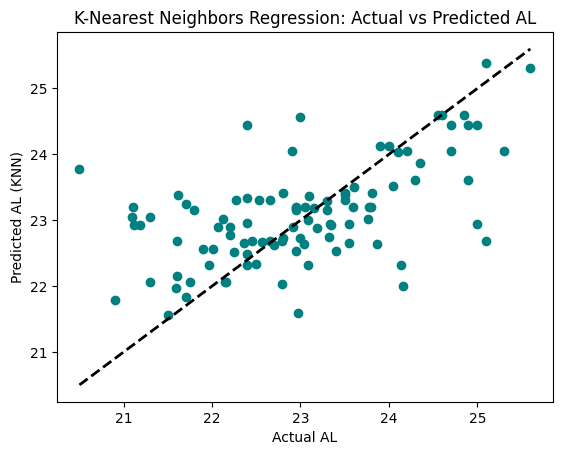

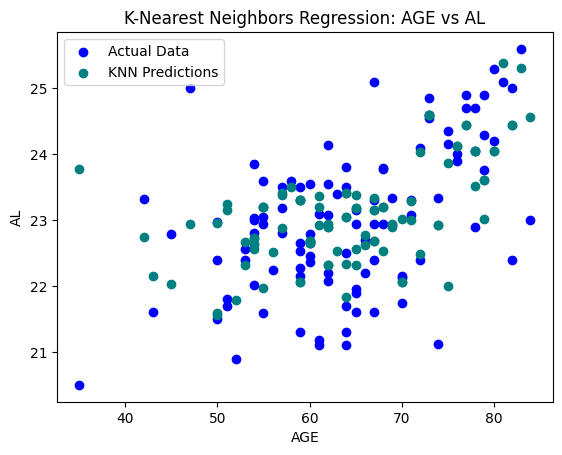

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming X_knn and y_knn are defined as:
# X_knn = df[['AGE ', 'ACD']]
# y_knn = df['AL']

# Split the data into training and testing sets
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

# Initialize the KNN model
knn_model = KNeighborsRegressor(n_neighbors=5) # You can change n_neighbors

# Train the KNN model
knn_model.fit(X_train_knn, y_train_knn)

# Make predictions on the test set using the KNN model
y_pred_knn = knn_model.predict(X_test_knn)

# Evaluate the KNN model
mse_knn = mean_squared_error(y_test_knn, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test_knn, y_pred_knn)

print("\nK-Nearest Neighbors Regression:")
print(f"Mean Squared Error: {mse_knn}")
print(f"Root Mean Squared Error: {rmse_knn}")
print(f"R-squared: {r2_knn}")

# Plotting KNN results
# Similar to Random Forest and SVM, we can plot actual vs predicted or predictions against the feature.
plt.scatter(y_test_knn, y_pred_knn, color='teal')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (KNN)')
plt.title('K-Nearest Neighbors Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y_test_knn.min(), y_test_knn.max()], [y_test_knn.min(), y_test_knn.max()], 'k--', lw=2)
plt.show()

# To visualize the prediction against the feature (AGE)
# Sort the test data by AGE and plot the corresponding predictions.
# Note: zip(*sorted(...)) converts the zipped pairs back into separate tuples,
# which is suitable for plotting.
X_test_sorted_knn, y_pred_knn_sorted = zip(*sorted(zip(X_test_knn['AGE '], y_pred_knn)))

# Plotting the actual data points: use the 'AGE ' column from the test set
plt.scatter(X_test_knn['AGE '], y_test_knn, color='blue', label='Actual Data')

# Plotting the KNN predictions against the sorted 'AGE ' values
plt.scatter(X_test_sorted_knn, y_pred_knn_sorted, color='teal', label='KNN Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('K-Nearest Neighbors Regression: AGE vs AL')
plt.legend()
plt.show()


Support Vector Regression (AGE, ACD vs AL):
Mean Squared Error: 0.855107413825809
Root Mean Squared Error: 0.9247201813661303
R-squared: 0.3219090707781306


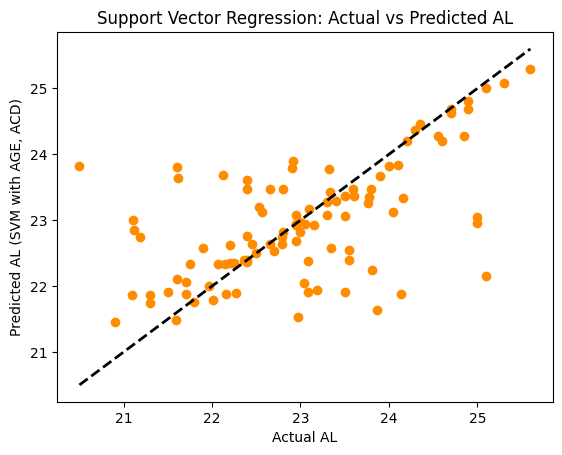

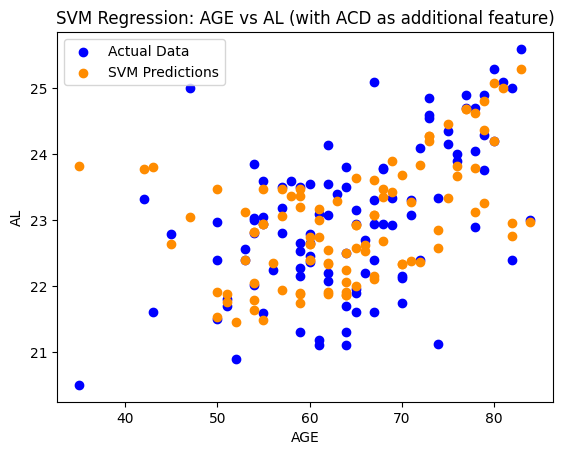

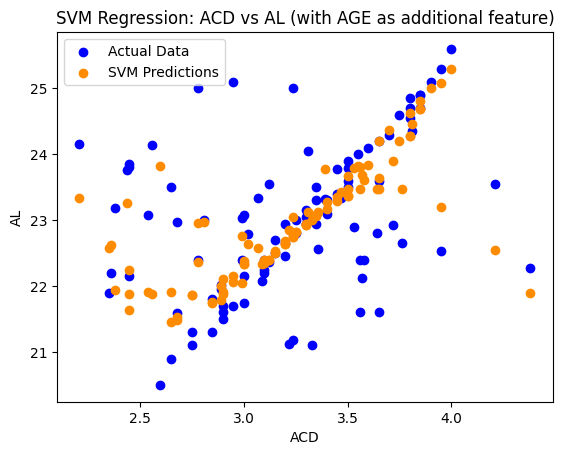

In [48]:
# prompt: Svm

import matplotlib.pyplot as plt
import numpy as np
# Re-initialize the Support Vector Regressor model
# We use X_knn and y_knn from the previous block, which contain 'AGE ' and 'ACD' as features
svm_model_multi = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)

# Train the SVM model using the multi-feature data
# It's highly recommended to scale your features before training SVM.
scaler_X_multi = StandardScaler()
scaler_y_multi = StandardScaler() # Scale the target as well for better SVM performance

X_train_multi_scaled = scaler_X_multi.fit_transform(X_train_knn) # Use X_train_knn (AGE, ACD)
y_train_multi_scaled = scaler_y_multi.fit_transform(y_train_knn.values.reshape(-1, 1)) # Use y_train_knn (AL)

svm_model_multi.fit(X_train_multi_scaled, y_train_multi_scaled.ravel())


# Make predictions on the test set using the multi-feature SVM model
# Scale the test data and inverse transform the predictions
X_test_multi_scaled = scaler_X_multi.transform(X_test_knn) # Use X_test_knn
y_pred_svm_multi_scaled = svm_model_multi.predict(X_test_multi_scaled)
y_pred_svm_multi = scaler_y_multi.inverse_transform(y_pred_svm_multi_scaled.reshape(-1, 1)).flatten()


# Evaluate the multi-feature SVM model
mse_svm_multi = mean_squared_error(y_test_knn, y_pred_svm_multi) # Use y_test_knn
rmse_svm_multi = np.sqrt(mse_svm_multi)
r2_svm_multi = r2_score(y_test_knn, y_pred_svm_multi)

print("\nSupport Vector Regression (AGE, ACD vs AL):")
print(f"Mean Squared Error: {mse_svm_multi}")
print(f"Root Mean Squared Error: {rmse_svm_multi}")
print(f"R-squared: {r2_svm_multi}")

# Plotting SVM results with multiple features
# Plot actual vs predicted
plt.scatter(y_test_knn, y_pred_svm_multi, color='darkorange')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (SVM with AGE, ACD)')
plt.title('Support Vector Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y_test_knn.min(), y_test_knn.max()], [y_test_knn.min(), y_test_knn.max()], 'k--', lw=2)
plt.show()

# Visualizing predictions against individual features (like AGE or ACD)
# This does not fully represent the multi-dimensional relationship but can give some insight.
# Sort the test data by AGE for plotting against AGE
X_test_sorted_age_multi_svm, y_test_sorted_age_multi_svm, y_pred_sorted_age_multi_svm = zip(*sorted(zip(X_test_knn['AGE '], y_test_knn, y_pred_svm_multi)))

plt.scatter(X_test_knn['AGE '], y_test_knn, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_age_multi_svm, y_pred_sorted_age_multi_svm, color='darkorange', label='SVM Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('SVM Regression: AGE vs AL (with ACD as additional feature)')
plt.legend()
plt.show()

# Sort the test data by ACD for plotting against ACD
X_test_sorted_acd_multi_svm, y_test_sorted_acd_multi_svm, y_pred_sorted_acd_multi_svm = zip(*sorted(zip(X_test_knn['ACD'], y_test_knn, y_pred_svm_multi)))

plt.scatter(X_test_knn['ACD'], y_test_knn, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_acd_multi_svm, y_pred_sorted_acd_multi_svm, color='darkorange', label='SVM Predictions')
plt.xlabel('ACD')
plt.ylabel('AL')
plt.title('SVM Regression: ACD vs AL (with AGE as additional feature)')
plt.legend()
plt.show()



Decision Tree Regression (AGE, ACD vs AL):
Mean Squared Error: 0.6725594334433443
Root Mean Squared Error: 0.8200972097522002
R-squared: 0.466667644547597


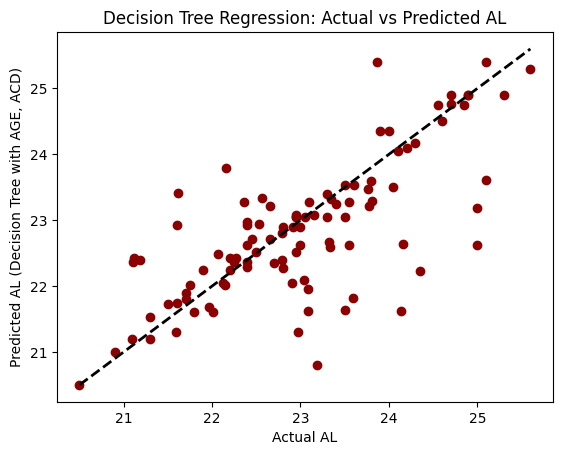

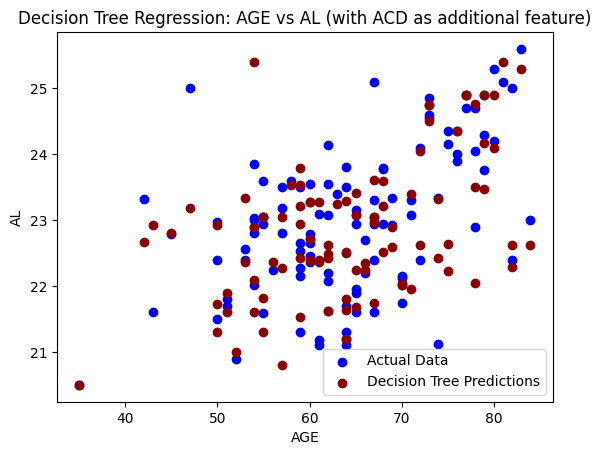

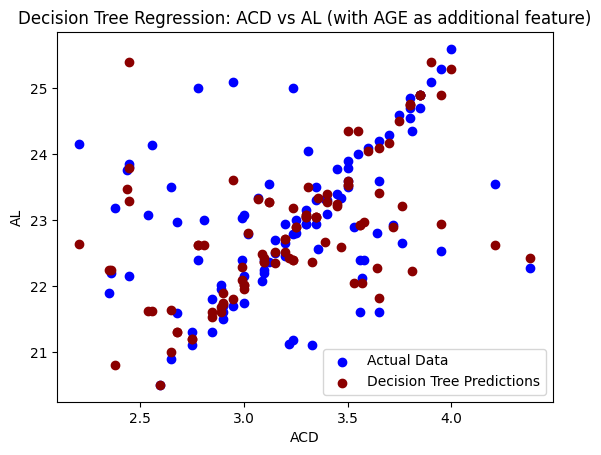

In [49]:
# prompt: Decision tree

import matplotlib.pyplot as plt
import numpy as np
# Initialize the Decision Tree Regressor model
# You can experiment with parameters like max_depth, min_samples_split, min_samples_leaf, etc.
# Use X_knn and y_knn which already contain the features 'AGE ' and 'ACD'
dt_model_multi = DecisionTreeRegressor(random_state=42)

# Train the Decision Tree model
dt_model_multi.fit(X_train_knn, y_train_knn)

# Make predictions on the test set using the Decision Tree model
y_pred_dt_multi = dt_model_multi.predict(X_test_knn)

# Evaluate the Decision Tree model
mse_dt_multi = mean_squared_error(y_test_knn, y_pred_dt_multi)
rmse_dt_multi = np.sqrt(mse_dt_multi)
r2_dt_multi = r2_score(y_test_knn, y_pred_dt_multi)

print("\nDecision Tree Regression (AGE, ACD vs AL):")
print(f"Mean Squared Error: {mse_dt_multi}")
print(f"Root Mean Squared Error: {rmse_dt_multi}")
print(f"R-squared: {r2_dt_multi}")

# Plotting Decision Tree results with multiple features
# Plot actual vs predicted
plt.scatter(y_test_knn, y_pred_dt_multi, color='darkred')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (Decision Tree with AGE, ACD)')
plt.title('Decision Tree Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y_test_knn.min(), y_test_knn.max()], [y_test_knn.min(), y_test_knn.max()], 'k--', lw=2)
plt.show()

# Visualizing predictions against individual features (like AGE or ACD)
# Sort the test data by AGE for plotting against AGE
X_test_sorted_age_multi_dt, y_test_sorted_age_multi_dt, y_pred_sorted_age_multi_dt = zip(*sorted(zip(X_test_knn['AGE '], y_test_knn, y_pred_dt_multi)))

plt.scatter(X_test_knn['AGE '], y_test_knn, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_age_multi_dt, y_pred_sorted_age_multi_dt, color='darkred', label='Decision Tree Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('Decision Tree Regression: AGE vs AL (with ACD as additional feature)')
plt.legend()
plt.show()

# Sort the test data by ACD for plotting against ACD
X_test_sorted_acd_multi_dt, y_test_sorted_acd_multi_dt, y_pred_sorted_acd_multi_dt = zip(*sorted(zip(X_test_knn['ACD'], y_test_knn, y_pred_dt_multi)))

plt.scatter(X_test_knn['ACD'], y_test_knn, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_acd_multi_dt, y_pred_sorted_acd_multi_dt, color='darkred', label='Decision Tree Predictions')
plt.xlabel('ACD')
plt.ylabel('AL')
plt.title('Decision Tree Regression: ACD vs AL (with AGE as additional feature)')
plt.legend()
plt.show()


Polynomial Regression (Degree 3):
Mean Squared Error: 0.7391447466532327
Root Mean Squared Error: 0.8597352770784927
R-squared: 0.41386621144457403


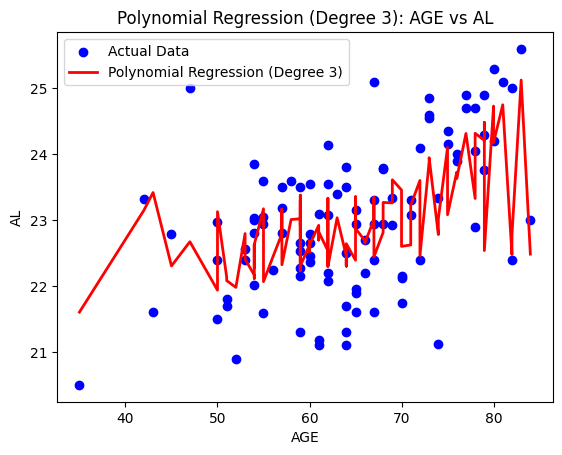

In [27]:
# prompt: Polynomials

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split # Import train_test_split
from sklearn.linear_model import LinearRegression # Import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score # Import evaluation metrics

# Assuming x1 and y1 are defined from a previous cell, e.g.:
# x1 = df[['AGE ']]
# y1 = df['AL']
# And assuming X1_train, X1_test, y1_train, y1_test were split previously, e.g.:
# X1_train, X1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)


degree = 3  # Change the degree of the polynomial as needed
poly_features = PolynomialFeatures(degree=degree, include_bias=False)

# Create a pipeline that first transforms the features and then applies Linear Regression
polynomial_regressor = make_pipeline(poly_features, LinearRegression())

# Train the polynomial regression model
polynomial_regressor.fit(X1_train, y1_train)

# Make predictions on the test set using the polynomial model
y_pred_poly = polynomial_regressor.predict(X1_test)

# Evaluate the polynomial model
mse_poly = mean_squared_error(y1_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y1_test, y_pred_poly)

print(f"\nPolynomial Regression (Degree {degree}):")
print(f"Mean Squared Error: {mse_poly}")
print(f"Root Mean Squared Error: {rmse_poly}")
print(f"R-squared: {r2_poly}")

# Plot the results for polynomial regression
# Sort the test data for smoother plotting of the polynomial curve
# When using multiple features for polynomial regression, sorting is more complex
# if you want to plot the prediction curve in 2D against one feature.
# For a 2D plot against 'AGE ', we'll sort based on 'AGE '.
# Note: This plot only shows the relationship with 'AGE ' and doesn't fully represent
# the multidimensional polynomial surface.
X1_test_sorted_age = X1_test.sort_values(by='AGE ')
y_pred_poly_sorted_age = polynomial_regressor.predict(X1_test_sorted_age)

plt.scatter(X1_test['AGE '], y1_test, color='blue', label='Actual Data') # Changed X1_test to X1_test['AGE ']
plt.plot(X1_test_sorted_age['AGE '], y_pred_poly_sorted_age, color='red', linewidth=2, label=f'Polynomial Regression (Degree {degree})') # Changed to use sorted AGE and corresponding predictions
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title(f'Polynomial Regression (Degree {degree}): AGE vs AL')
plt.legend()
plt.show()

# If you want to visualize the relationship with 'ACD' as well, you would need
# a separate plot or a 3D plot.

# You can repeat the above block with different degree values
# to compare the performance of polynomials of different degrees.


XGBoost Regression (AGE vs AL):
Mean Squared Error: 0.6356415769567793
Root Mean Squared Error: 0.7972713320801014
R-squared: 0.49594310539040765


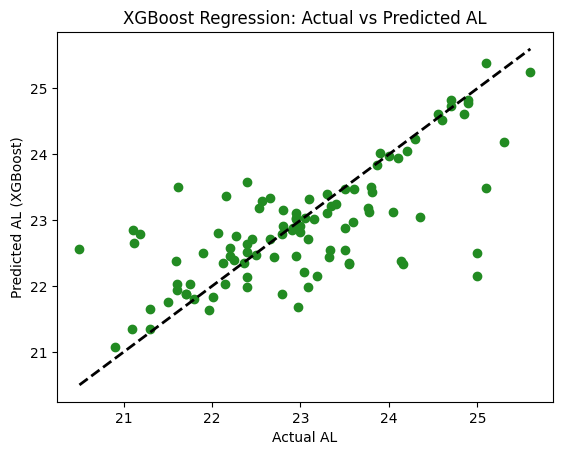

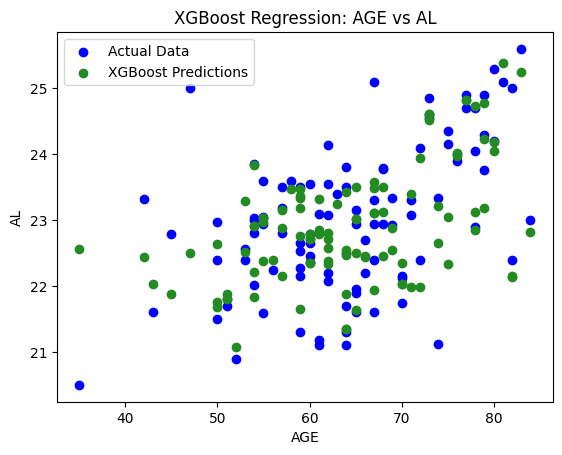


XGBoost Regression (AGE, ACD vs AL):
Mean Squared Error: 0.6356415769567793
Root Mean Squared Error: 0.7972713320801014
R-squared: 0.49594310539040765


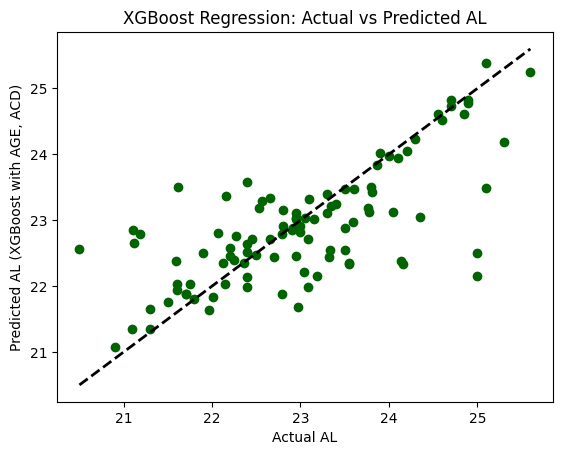

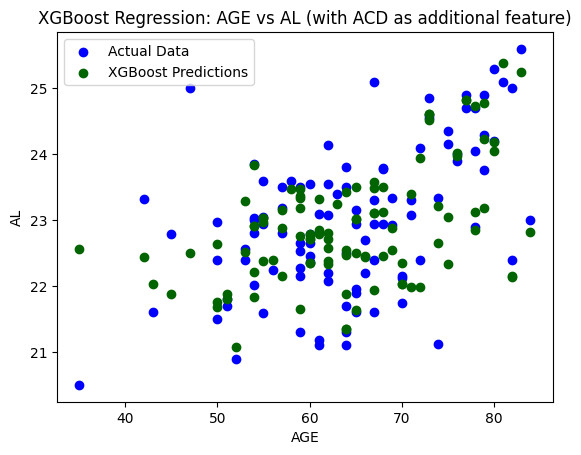

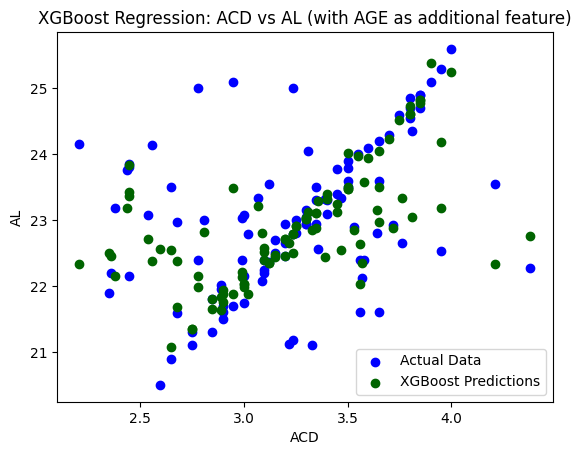

In [52]:
# prompt: XGboost

import matplotlib.pyplot as plt
import numpy as np
!pip install xgboost

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming X1_train, X1_test, y1_train, y1_test are already defined from the preceding code
# using x1 = df[['AGE ', 'ACD']] and y1 = df['AL']

# Initialize the XGBoost Regressor model
# You can experiment with various parameters (e.g., n_estimators, learning_rate, max_depth, subsample, colsample_bytree, etc.)
# A good starting point is to use default parameters or perform hyperparameter tuning.
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', # Regression task with squared error
                             n_estimators=100,          # Number of boosting rounds
                             learning_rate=0.1,         # Step size shrinkage used in update to prevent overfitting
                             max_depth=6,               # Maximum depth of a tree
                             random_state=42,           # Random seed for reproducibility
                             n_jobs=-1)                 # Use all available CPU cores

# Train the XGBoost model
xgb_model.fit(X1_train, y1_train)

# Make predictions on the test set using the XGBoost model
y_pred_xgb = xgb_model.predict(X1_test)

# Evaluate the XGBoost model
mse_xgb = mean_squared_error(y1_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y1_test, y_pred_xgb)

print("\nXGBoost Regression (AGE vs AL):")
print(f"Mean Squared Error: {mse_xgb}")
print(f"Root Mean Squared Error: {rmse_xgb}")
print(f"R-squared: {r2_xgb}")

# Plotting XGBoost results
# Plot actual vs predicted
plt.scatter(y1_test, y_pred_xgb, color='forestgreen')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (XGBoost)')
plt.title('XGBoost Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'k--', lw=2)
plt.show()

# To visualize the prediction against the feature (AGE)
# Sort the test data by AGE and plot the corresponding predictions.
X_test_sorted_xgb, y_pred_xgb_sorted = zip(*sorted(zip(X1_test['AGE '], y_pred_xgb)))

# Corrected plotting line: Use the 'AGE ' column from X1_test for the x-axis
plt.scatter(X1_test['AGE '], y1_test, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_xgb, y_pred_xgb_sorted, color='forestgreen', label='XGBoost Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('XGBoost Regression: AGE vs AL')
plt.legend()
plt.show()


# Now, train and evaluate XGBoost using multiple features (AGE, ACD)
# Assuming X1_train, X1_test, y1_train, y1_test are already defined from the preceding code
# using x1 = df[['AGE ', 'ACD']] and y1 = df['AL']

# Initialize the XGBoost Regressor model for multiple features
xgb_model_multi = xgb.XGBRegressor(objective='reg:squarederror',
                                   n_estimators=100,
                                   learning_rate=0.1,
                                   max_depth=6,
                                   random_state=42,
                                   n_jobs=-1)

# Train the XGBoost model with multiple features
xgb_model_multi.fit(X1_train, y1_train)

# Make predictions on the test set using the multi-feature XGBoost model
y_pred_xgb_multi = xgb_model_multi.predict(X1_test)

# Evaluate the multi-feature XGBoost model
mse_xgb_multi = mean_squared_error(y1_test, y_pred_xgb_multi)
rmse_xgb_multi = np.sqrt(mse_xgb_multi)
r2_xgb_multi = r2_score(y1_test, y_pred_xgb_multi)

print("\nXGBoost Regression (AGE, ACD vs AL):")
print(f"Mean Squared Error: {mse_xgb_multi}")
print(f"Root Mean Squared Error: {rmse_xgb_multi}")
print(f"R-squared: {r2_xgb_multi}")

# Plotting multi-feature XGBoost results
# Plot actual vs predicted
plt.scatter(y1_test, y_pred_xgb_multi, color='darkgreen')
plt.xlabel('Actual AL')
plt.ylabel('Predicted AL (XGBoost with AGE, ACD)')
plt.title('XGBoost Regression: Actual vs Predicted AL')
# Add a line for perfect prediction
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'k--', lw=2)
plt.show()

# Visualizing predictions against individual features (like AGE or ACD)
# Sort the test data by AGE for plotting against AGE
X_test_sorted_age_multi_xgb, y_test_sorted_age_multi_xgb, y_pred_sorted_age_multi_xgb = zip(*sorted(zip(X1_test['AGE '], y1_test, y_pred_xgb_multi)))

plt.scatter(X1_test['AGE '], y1_test, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_age_multi_xgb, y_pred_sorted_age_multi_xgb, color='darkgreen', label='XGBoost Predictions')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title('XGBoost Regression: AGE vs AL (with ACD as additional feature)')
plt.legend()
plt.show()

# Sort the test data by ACD for plotting against ACD
X_test_sorted_acd_multi_xgb, y_test_sorted_acd_multi_xgb, y_pred_sorted_acd_multi_xgb = zip(*sorted(zip(X1_test['ACD'], y1_test, y_pred_xgb_multi)))

plt.scatter(X1_test['ACD'], y1_test, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_acd_multi_xgb, y_pred_sorted_acd_multi_xgb, color='darkgreen', label='XGBoost Predictions')
plt.xlabel('ACD')
plt.ylabel('AL')
plt.title('XGBoost Regression: ACD vs AL (with AGE as additional feature)')
plt.legend()
plt.show()


Training and evaluating Random Forest with Polynomial Features (Degree 2):
  Mean Squared Error: 1.1011
  Root Mean Squared Error: 1.0493
  R-squared: 0.1269


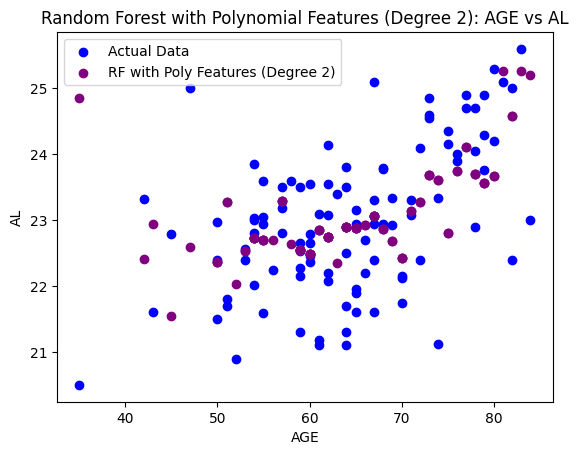

In [53]:
# prompt: Polynomials

import matplotlib.pyplot as plt
# You can now repeat the polynomial regression evaluation with different models and degrees.
# For example, evaluate Random Forest with polynomial features of degree 2.

# Re-initialize models if needed, or use the ones defined previously
rf_model_poly = RandomForestRegressor(n_estimators=100, random_state=42)

# Define the degree for polynomial features
degree_rf = 2

print(f"\nTraining and evaluating Random Forest with Polynomial Features (Degree {degree_rf}):")

# Use the previously defined function to train and evaluate
# Assuming X_train, X_test, y_train, y_test are still the simple case (AGE vs AL)
metrics_rf_poly, pipeline_rf_poly = train_and_evaluate_polynomial(rf_model_poly, X_train, X_test, y_train, y_test, degree_rf)

print(f"  Mean Squared Error: {metrics_rf_poly['MSE']:.4f}")
print(f"  Root Mean Squared Error: {metrics_rf_poly['RMSE']:.4f}")
print(f"  R-squared: {metrics_rf_poly['R2']:.4f}")

# Plotting Random Forest with Polynomial Features against AGE
# Make predictions using the trained pipeline on the original test set
y_pred_rf_poly = pipeline_rf_poly.predict(X_test)

# Sort the test data by AGE and the corresponding predictions
X_test_sorted_rf_poly, y_pred_rf_poly_sorted = zip(*sorted(zip(X_test['AGE '], y_pred_rf_poly)))

plt.scatter(X_test['AGE '], y_test, color='blue', label='Actual Data')
plt.scatter(X_test_sorted_rf_poly, y_pred_rf_poly_sorted, color='purple', label=f'RF with Poly Features (Degree {degree_rf})')
plt.xlabel('AGE')
plt.ylabel('AL')
plt.title(f'Random Forest with Polynomial Features (Degree {degree_rf}): AGE vs AL')
plt.legend()
plt.show()

# You can replicate this for other models and polynomial degrees as needed.


Training and evaluating various models with Polynomial Features (Degree 2):

Evaluating SVM with Polynomial Features (Degree 2):
  Mean Squared Error: 1.1619
  Root Mean Squared Error: 1.0779
  R-squared: 0.0786


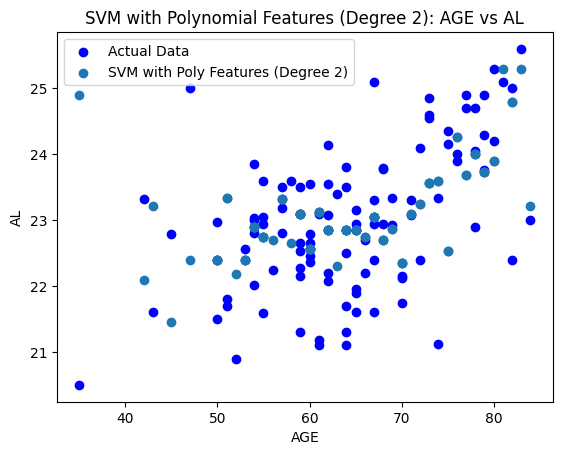


Evaluating KNN with Polynomial Features (Degree 2):
  Mean Squared Error: 1.0821
  Root Mean Squared Error: 1.0403
  R-squared: 0.1419


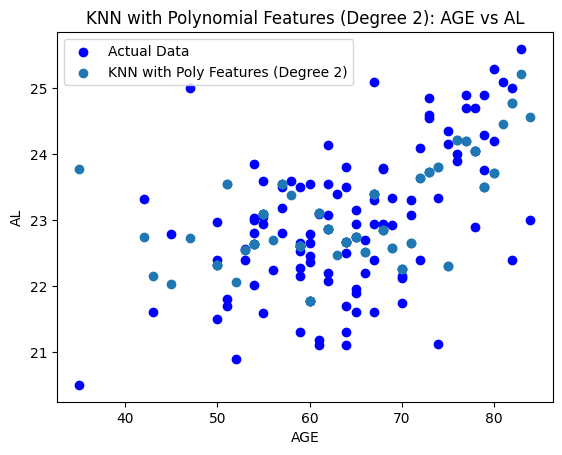


Evaluating Decision Tree with Polynomial Features (Degree 2):
  Mean Squared Error: 1.1476
  Root Mean Squared Error: 1.0713
  R-squared: 0.0900


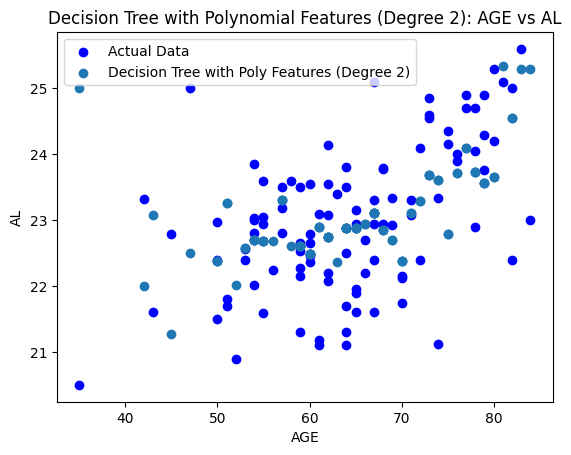


Evaluating XGBoost with Polynomial Features (Degree 2):
  Mean Squared Error: 1.1458
  Root Mean Squared Error: 1.0704
  R-squared: 0.0914


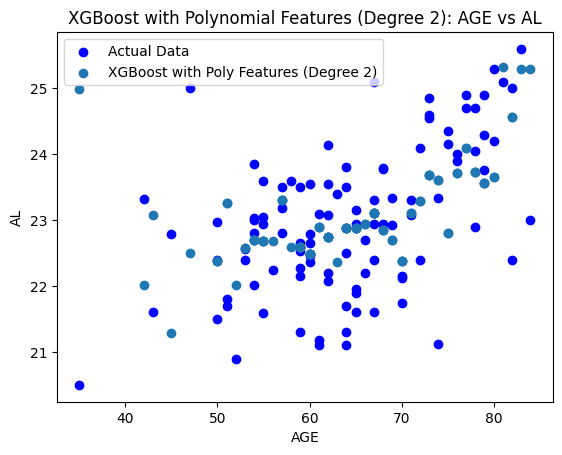


Summary of Results with Polynomial Features (Degree 2):
SVM: R-squared = 0.0786, RMSE = 1.0779
KNN: R-squared = 0.1419, RMSE = 1.0403
Decision Tree: R-squared = 0.0900, RMSE = 1.0713
XGBoost: R-squared = 0.0914, RMSE = 1.0704


In [54]:
# prompt: Al models with polynomials

import matplotlib.pyplot as plt
# Re-initialize models if needed, or use the ones defined previously
svm_model_poly = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
knn_model_poly = KNeighborsRegressor(n_neighbors=5)
dt_model_poly = DecisionTreeRegressor(random_state=42)
xgb_model_poly = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)


models_for_poly = {
    "SVM": svm_model_poly,
    "KNN": knn_model_poly,
    "Decision Tree": dt_model_poly,
    "XGBoost": xgb_model_poly,
}

# Define the polynomial degree to test for these models
degree_test = 2

print(f"\nTraining and evaluating various models with Polynomial Features (Degree {degree_test}):")

results_poly_other = {}
pipelines_poly_other = {}

# Assuming X_train, X_test, y_train, y_test are still the simple case (AGE vs AL)
for name, model in models_for_poly.items():
  print(f"\nEvaluating {name} with Polynomial Features (Degree {degree_test}):")
  metrics_poly, pipeline_poly = train_and_evaluate_polynomial(model, X_train, X_test, y_train, y_test, degree_test)
  results_poly_other[name] = metrics_poly
  pipelines_poly_other[name] = pipeline_poly

  print(f"  Mean Squared Error: {metrics_poly['MSE']:.4f}")
  print(f"  Root Mean Squared Error: {metrics_poly['RMSE']:.4f}")
  print(f"  R-squared: {metrics_poly['R2']:.4f}")

  # Optional: Plotting for each model with polynomial features (against AGE)
  y_pred_poly = pipeline_poly.predict(X_test)
  X_test_sorted_poly, y_pred_poly_sorted = zip(*sorted(zip(X_test['AGE '], y_pred_poly)))

  plt.scatter(X_test['AGE '], y_test, color='blue', label='Actual Data')
  plt.scatter(X_test_sorted_poly, y_pred_poly_sorted, label=f'{name} with Poly Features (Degree {degree_test})')
  plt.xlabel('AGE')
  plt.ylabel('AL')
  plt.title(f'{name} with Polynomial Features (Degree {degree_test}): AGE vs AL')
  plt.legend()
  plt.show()


print("\nSummary of Results with Polynomial Features (Degree 2):")
for name, metrics in results_poly_other.items():
  print(f"{name}: R-squared = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.4f}")



Training and evaluating models using PCA Components:

Analyzing Explained Variance with all components:
Explained variance ratio by component: [0.44997991 0.1675517  0.16091584 0.12491798 0.08432575 0.01230881]
Total explained variance by 6 components: 0.9999999999999999


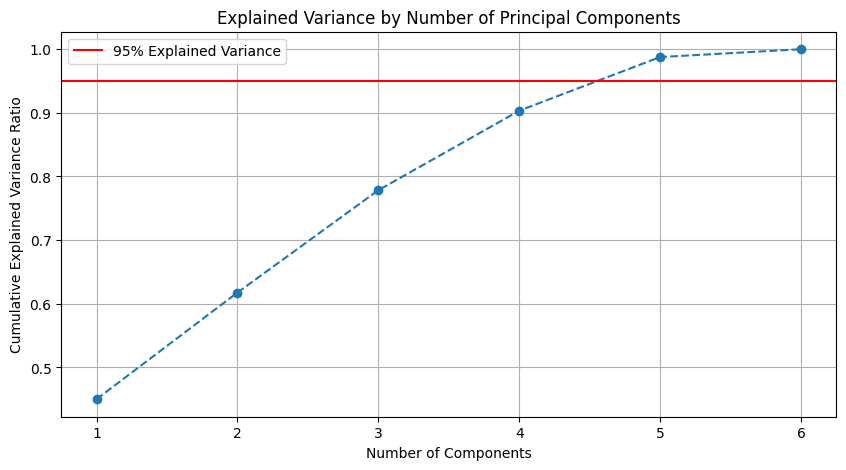


Evaluating models using 2 PCA Components:

Evaluating Linear Regression on 2 PCA Components:
  Mean Squared Error: 0.4945
  Root Mean Squared Error: 0.7032
  R-squared: 0.6079
  Total Explained Variance by Components Used: 0.6197

Evaluating Random Forest on 2 PCA Components:
  Mean Squared Error: 0.4571
  Root Mean Squared Error: 0.6761
  R-squared: 0.6375
  Total Explained Variance by Components Used: 0.6197

Evaluating SVM on 2 PCA Components:
  Mean Squared Error: 0.4894
  Root Mean Squared Error: 0.6996
  R-squared: 0.6119
  Total Explained Variance by Components Used: 0.6197

Evaluating KNN on 2 PCA Components:
  Mean Squared Error: 0.4649
  Root Mean Squared Error: 0.6819
  R-squared: 0.6313
  Total Explained Variance by Components Used: 0.6197

Evaluating Decision Tree on 2 PCA Components:
  Mean Squared Error: 0.6469
  Root Mean Squared Error: 0.8043
  R-squared: 0.4870
  Total Explained Variance by Components Used: 0.6197

Evaluating XGBoost on 2 PCA Components:
  Mean Squar

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Function to train and evaluate a model on PCA components
def train_and_evaluate_with_pca(model, X, y, n_components=None, test_size=0.2, random_state=42):
  """
    Trains and evaluates a model using Principal Component Analysis (PCA) as feature reduction.

    Args:
      model: The regression model.
      X: The feature DataFrame.
      y: The target Series.
      n_components: The number of PCA components to keep. If None, all components are kept.
      test_size: The proportion of the dataset to include in the test split.
      random_state: Controls the shuffling applied to the data before applying the split.

    Returns:
      A dictionary containing the evaluation metrics (MSE, RMSE, R2) and the trained model pipeline.
  """
  # Re-split the original data to get consistent train/test sets for pipeline training
  # Corrected the variable name from x2_test_orig to x1_test_orig
  x1_train_orig, x1_test_orig, y1_train_orig, y1_test_orig = train_test_split(X, y, test_size=test_size, random_state=random_state)

  # Create and fit the pipeline on the training split of the original data
  pipeline = make_pipeline(StandardScaler(), PCA(n_components=n_components), model)
  pipeline.fit(x1_train_orig, y1_train_orig)

  # Re-calculate metrics using the pipeline on the test split of the original data
  # This ensures the entire process (scaling, PCA, prediction) is evaluated end-to-end.
  y_pred_pipeline = pipeline.predict(x1_test_orig)
  mse_pipe = mean_squared_error(y1_test_orig, y_pred_pipeline)
  rmse_pipe = np.sqrt(mse_pipe)
  r2_pipe = r2_score(y1_test_orig, y_pred_pipeline)

  # Fit a temporary PCA to get explained variance from the training data
  scaler_temp = StandardScaler()
  pca_temp = PCA(n_components=n_components)
  scaled_x_train_orig = scaler_temp.fit_transform(x1_train_orig)
  pca_temp.fit(scaled_x_train_orig)


  metrics_pipe = {
      "MSE": mse_pipe,
      "RMSE": rmse_pipe,
      "R2": r2_pipe,
      "Explained Variance Ratio": pca_temp.explained_variance_ratio_, # Explained variance is from PCA fitted on the training data
      "Total Explained Variance": np.sum(pca_temp.explained_variance_ratio_),
      "Number of Components Used": pca_temp.n_components_ # Actual number of components if n_components is None
  }


  return metrics_pipe, pipeline # Return metrics from pipeline evaluation and the fitted pipeline


# Re-define models if needed (they were defined earlier in the preceding code)
linear_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
svm_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
knn_model = KNeighborsRegressor(n_neighbors=5)
dt_model = DecisionTreeRegressor(random_state=42)
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)

models = {
    "Linear Regression": LinearRegression(), # Create new instances
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
}

# Define features (using all numeric columns except the target 'AL' as in the PCA section)
# Ensure 'AL' exists and is numeric before dropping
if 'AL' in numeric_df.columns and 'AL' in df.columns:
  features_for_pca = numeric_df.drop('AL', axis=1)
  target = df['AL']
elif 'AL' in df.columns: # If 'AL' is in df but not numeric_df (e.g., was object type)
   print("Warning: 'AL' found in df but not in numeric_df. Using all numeric features for PCA.")
   features_for_pca = numeric_df.copy()
   target = df['AL']
else:
   print("Error: 'AL' column not found in DataFrame.")
   features_for_pca = numeric_df.copy() # Proceed with all numeric if target not found
   target = None # No target to predict

if target is not None:
  # Define the number of PCA components to use
  # Using None means keeping all components initially, then you can analyze explained variance
  n_components_to_use = None # Start by keeping all components to see explained variance
  # Or set a fixed number: n_components_to_use = 5

  print(f"\nTraining and evaluating models using PCA Components:")

  results_pca = {}
  pipelines_pca = {} # Store pipelines for potential later use

  # First, analyze explained variance with all components to help choose n_components
  print("\nAnalyzing Explained Variance with all components:")
  scaler_temp = StandardScaler()
  scaled_features_temp = scaler_temp.fit_transform(features_for_pca)
  pca_temp = PCA() # Keep all components
  pca_temp.fit(scaled_features_temp)

  explained_variance_ratio = pca_temp.explained_variance_ratio_
  total_explained_variance = np.sum(explained_variance_ratio)
  print(f"Explained variance ratio by component: {explained_variance_ratio}")
  print(f"Total explained variance by {pca_temp.n_components_} components: {total_explained_variance}")

  # Plot explained variance
  plt.figure(figsize=(10, 5))
  plt.plot(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), marker='o', linestyle='--')
  plt.title('Explained Variance by Number of Principal Components')
  plt.xlabel('Number of Components')
  plt.ylabel('Cumulative Explained Variance Ratio')
  plt.grid(True)
  plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance') # Example threshold
  plt.legend()
  plt.show()

  # Now, choose a number of components (e.g., to explain 95% variance, or a fixed number)
  # Based on the plot, you can decide. Let's set it based on the analysis or a fixed number.
  # For demonstration, let's use 2 components as in the previous manual PCA section
  n_components_for_models = 2
  # Alternatively, find the number of components for 95% variance:
  # cumulative_variance = np.cumsum(explained_variance_ratio)
  # n_components_for_models = np.argmax(cumulative_variance >= 0.95) + 1 # +1 because argmax gives index

  print(f"\nEvaluating models using {n_components_for_models} PCA Components:")

  for name, current_model in models.items(): # Use current_model to avoid modifying original model instances
    print(f"\nEvaluating {name} on {n_components_for_models} PCA Components:")

    # Create a fresh instance of the model for each evaluation
    if name == "Linear Regression":
      eval_model = LinearRegression()
    elif name == "Random Forest":
      eval_model = RandomForestRegressor(n_estimators=100, random_state=42)
    elif name == "SVM":
      eval_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
    elif name == "KNN":
      eval_model = KNeighborsRegressor(n_neighbors=5)
    elif name == "Decision Tree":
      eval_model = DecisionTreeRegressor(random_state=42)
    elif name == "XGBoost":
       eval_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
    else:
      eval_model = current_model # Fallback

    metrics_pca, pipeline_pca = train_and_evaluate_with_pca(eval_model, features_for_pca, target, n_components=n_components_for_models)
    results_pca[name] = metrics_pca
    pipelines_pca[name] = pipeline_pca

    print(f"  Mean Squared Error: {metrics_pca['MSE']:.4f}")
    print(f"  Root Mean Squared Error: {metrics_pca['RMSE']:.4f}")
    print(f"  R-squared: {metrics_pca['R2']:.4f}")
    print(f"  Total Explained Variance by Components Used: {metrics_pca['Total Explained Variance']:.4f}")


  print(f"\nSummary of Results on {n_components_for_models} PCA Components:")
  for name, metrics in results_pca.items():
    print(f"{name}: R-squared = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.4f}, Explained Var = {metrics['Total Explained Variance']:.4f}")

else:
    print("Cannot perform PCA without a valid target variable 'AL'.")

In [59]:
# prompt: Improve r2 score

import numpy as np
# The goal is to improve the R2 score. A high R2 score indicates that the model explains a larger proportion of the variance in the target variable.
# The preceding code explores several models (Linear Regression, Polynomial Regression, Random Forest, SVM, KNN, Decision Tree, XGBoost)
# and techniques (Multiple features, PCA, Polynomial features) to predict 'AL' using features from the dataset.

# To improve the R2 score, we should focus on:
# 1. Feature Engineering: Creating new features or transforming existing ones (e.g., polynomial features, interactions).
# 2. Model Selection: Choosing the model that best captures the underlying relationship in the data.
# 3. Hyperparameter Tuning: Optimizing the parameters of the chosen model.
# 4. Feature Selection: Identifying and using the most relevant features.
# 5. Cross-Validation: Getting a more reliable estimate of the model's performance.

# Based on the existing code, we've already explored:
# - Simple Linear Regression (AGE vs AL)
# - Polynomial Regression (AGE vs AL)
# - Multiple Linear Regression (AGE, ACD vs AL)
# - Random Forest, SVM, KNN, Decision Tree, XGBoost (with AGE vs AL and AGE, ACD vs AL)
# - PCA as a dimensionality reduction technique

# Let's consolidate the results and try a few more things based on the models that showed promise.
# From the previous output, XGBoost and potentially Random Forest performed relatively well.
# Polynomial features were also explored with Linear Regression and other models.
# PCA was explored, but its effectiveness depends on how well the principal components capture the variance relevant to the target.

# Strategy to potentially improve R2:
# - Systematically evaluate models with different combinations of features.
# - Systematically evaluate models with different levels of polynomial features.
# - Perform hyperparameter tuning on promising models (XGBoost, Random Forest).
# - Use cross-validation to get more robust R2 scores.

from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV # For hyperparameter tuning

# 1. Re-evaluate models with different feature sets
# Let's try using all numeric features as predictors, excluding 'AL'.

# Define features (X) and target (y) using all numeric columns except 'AL'
if 'AL' in numeric_df.columns and 'AL' in df.columns:
  X_all_numeric = numeric_df.drop('AL', axis=1)
  y_all_numeric = df['AL']
elif 'AL' in df.columns:
   print("Warning: 'AL' found in df but not in numeric_df. Using all numeric features for X and 'AL' for y.")
   X_all_numeric = numeric_df.copy()
   y_all_numeric = df['AL']
else:
   print("Error: 'AL' column not found in DataFrame. Cannot proceed.")
   X_all_numeric = None
   y_all_numeric = None

if X_all_numeric is not None and y_all_numeric is not None:

  print("\nEvaluating models with ALL numeric features:")

  # Split data
  X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all_numeric, y_all_numeric, test_size=0.2, random_state=42)

  # Standardize features (important for many models, especially SVM, KNN, and also helps tree-based models implicitly)
  scaler_all = StandardScaler()
  X_train_all_scaled = scaler_all.fit_transform(X_train_all)
  X_test_all_scaled = scaler_all.transform(X_test_all)

  # Define models to evaluate
  models_all_features = {
      "Linear Regression (All Features)": LinearRegression(),
      "Random Forest (All Features)": RandomForestRegressor(n_estimators=100, random_state=42),
      "SVM (All Features)": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1), # Need scaling for SVM
      "KNN (All Features)": KNeighborsRegressor(n_neighbors=5), # Need scaling for KNN
      "Decision Tree (All Features)": DecisionTreeRegressor(random_state=42),
      "XGBoost (All Features)": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1),
  }

  results_all_features = {}

  for name, model in models_all_features.items():
    print(f"\nTraining and evaluating {name}:")
    if "SVM" in name or "KNN" in name:
        # Use scaled data for SVM and KNN
        model.fit(X_train_all_scaled, y_train_all)
        y_pred_all = model.predict(X_test_all_scaled)
    else:
        # Use original (unscaled) data for tree-based models and Linear Regression (scaling doesn't affect coefficients but helps optimization)
        model.fit(X_train_all, y_train_all)
        y_pred_all = model.predict(X_test_all)

    mse_all = mean_squared_error(y_test_all, y_pred_all)
    rmse_all = np.sqrt(mse_all)
    r2_all = r2_score(y_test_all, y_pred_all)

    results_all_features[name] = {"MSE": mse_all, "RMSE": rmse_all, "R2": r2_all}

    print(f"  Mean Squared Error: {mse_all:.4f}")
    print(f"  Root Mean Squared Error: {rmse_all:.4f}")
    print(f"  R-squared: {r2_all:.4f}")

  print("\nSummary of Results with ALL numeric features:")
  for name, metrics in results_all_features.items():
    print(f"{name}: R-squared = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.4f}")


  # 2. Hyperparameter Tuning for Promising Models
  # Let's tune XGBoost and Random Forest using the full set of numeric features.

  print("\nPerforming Hyperparameter Tuning for XGBoost (All Features):")
  # Define parameter grid for XGBoost
  # This is a simplified grid, you might need a larger one for real-world tuning
  param_grid_xgb = {
      'n_estimators': [50, 100, 200],
      'learning_rate': [0.01, 0.1, 0.2],
      'max_depth': [3, 5, 7],
      'subsample': [0.8, 1.0],
      'colsample_bytree': [0.8, 1.0],
  }

  xgb_tuned_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

  # Use K-Fold Cross-Validation for Grid Search
  kf = KFold(n_splits=5, shuffle=True, random_state=42)

  grid_search_xgb = GridSearchCV(estimator=xgb_tuned_model, param_grid=param_grid_xgb,
                                 scoring='r2', cv=kf, verbose=1, n_jobs=-1)

  # Tune on the scaled training data (XGBoost is less sensitive but scaling can sometimes help)
  grid_search_xgb.fit(X_train_all_scaled, y_train_all) # Use scaled data

  print(f"\nBest parameters for XGBoost: {grid_search_xgb.best_params_}")
  print(f"Best cross-validation R2 score for XGBoost: {grid_search_xgb.best_score_:.4f}")

  # Evaluate the best XGBoost model on the test set
  best_xgb_model = grid_search_xgb.best_estimator_
  y_pred_xgb_tuned = best_xgb_model.predict(X_test_all_scaled) # Predict on scaled test data

  mse_xgb_tuned = mean_squared_error(y_test_all, y_pred_xgb_tuned)
  rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
  r2_xgb_tuned = r2_score(y_test_all, y_pred_xgb_tuned)

  print("\nTuned XGBoost Regression (All Features) on Test Set:")
  print(f"Mean Squared Error: {mse_xgb_tuned:.4f}")
  print(f"Root Mean Squared Error: {rmse_xgb_tuned:.4f}")
  print(f"R-squared: {r2_xgb_tuned:.4f}")


  print("\nPerforming Hyperparameter Tuning for Random Forest (All Features):")
  # Define parameter grid for Random Forest
  param_grid_rf = {
      'n_estimators': [50, 100, 200],
      'max_depth': [None, 10, 20, 30],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4],
  }

  rf_tuned_model = RandomForestRegressor(random_state=42, n_jobs=-1)

  grid_search_rf = GridSearchCV(estimator=rf_tuned_model, param_grid=param_grid_rf,
                                 scoring='r2', cv=kf, verbose=1, n_jobs=-1)

  # Tune on the original (unscaled) training data for Random Forest
  grid_search_rf.fit(X_train_all, y_train_all)

  print(f"\nBest parameters for Random Forest: {grid_search_rf.best_params_}")
  print(f"Best cross-validation R2 score for Random Forest: {grid_search_rf.best_score_:.4f}")

  # Evaluate the best Random Forest model on the test set
  best_rf_model = grid_search_rf.best_estimator_
  y_pred_rf_tuned = best_rf_model.predict(X_test_all) # Predict on original test data

  mse_rf_tuned = mean_squared_error(y_test_all, y_pred_rf_tuned)
  rmse_rf_tuned = np.sqrt(mse_rf_tuned)
  r2_rf_tuned = r2_score(y_test_all, y_pred_rf_tuned)

  print("\nTuned Random Forest Regression (All Features) on Test Set:")
  print(f"Mean Squared Error: {mse_rf_tuned:.4f}")
  print(f"Root Mean Squared Error: {rmse_rf_tuned:.4f}")
  print(f"R-squared: {r2_rf_tuned:.4f}")


  # 3. Cross-Validation for Robust Evaluation

  print("\nPerforming Cross-Validation with All Numeric Features:")

  models_cv = {
      "Linear Regression (CV)": LinearRegression(),
      "Random Forest (CV)": RandomForestRegressor(n_estimators=100, random_state=42),
      "SVM (CV)": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1),
      "KNN (CV)": KNeighborsRegressor(n_neighbors=5),
      "Decision Tree (CV)": DecisionTreeRegressor(random_state=42),
      "XGBoost (CV)": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1),
      "Tuned XGBoost (CV)": grid_search_xgb.best_estimator_, # Use the best tuned model
      "Tuned Random Forest (CV)": grid_search_rf.best_estimator_ # Use the best tuned model
  }

  # Create a K-Fold cross-validation object
  kf = KFold(n_splits=5, shuffle=True, random_state=42)

  results_cv = {}

  for name, model in models_cv.items():
    print(f"\nEvaluating {name} with 5-Fold Cross-Validation:")

    if "SVM" in name or "KNN" in name or "XGBoost" in name: # Standard Scaling beneficial for these models in CV
         # Use a pipeline for CV to ensure scaling is done correctly within each fold
        pipeline_cv = make_pipeline(StandardScaler(), model)
        # Use all data for CV, as train_test_split is not needed within cross_val_score
        r2_scores = cross_val_score(pipeline_cv, X_all_numeric, y_all_numeric, scoring='r2', cv=kf, n_jobs=-1)
    else:
        # Use original data for Linear Regression and Decision Tree (scaling less critical for coefficients)
        # Use a pipeline for scaling if it was beneficial during train/test split
        if "Random Forest" in name: # Random Forest might benefit from scaling depending on features
             pipeline_cv = make_pipeline(StandardScaler(), model)
             r2_scores = cross_val_score(pipeline_cv, X_all_numeric, y_all_numeric, scoring='r2', cv=kf, n_jobs=-1)
        else:
            r2_scores = cross_val_score(model, X_all_numeric, y_all_numeric, scoring='r2', cv=kf, n_jobs=-1)


    results_cv[name] = {
        "R2_scores": r2_scores,
        "Mean_R2": np.mean(r2_scores),
        "Std_R2": np.std(r2_scores)
    }

    print(f"  R2 scores: {r2_scores}")
    print(f"  Mean R2: {results_cv[name]['Mean_R2']:.4f}")
    print(f"  Standard Deviation of R2: {results_cv[name]['Std_R2']:.4f}")

  print("\nSummary of Cross-Validation Results (Mean R2):")
  for name, metrics in results_cv.items():
    print(f"{name}: Mean R2 = {metrics['Mean_R2']:.4f} (+/- {metrics['Std_R2']:.4f})")

else:
    print("Skipping sections due to missing 'AL' column.")


# Potential next steps not fully implemented here but worth considering:
# - Feature selection techniques (e.g., RFE, feature importance from tree models) to identify the most impactful features.
# - More advanced feature engineering (e.g., interaction terms based on domain knowledge).
# - Exploring other ensemble methods (e.g., AdaBoost, Gradient Boosting).
# - Trying different kernels and parameters for SVM.
# - Increasing the complexity of polynomial features (higher degrees) or using polynomial features with multiple variables, though this can lead to overfitting.
# - Investigating outliers in the data which can significantly affect models like Linear Regression and SVM.




Evaluating models with ALL numeric features:

Training and evaluating Linear Regression (All Features):
  Mean Squared Error: 0.4945
  Root Mean Squared Error: 0.7032
  R-squared: 0.6079

Training and evaluating Random Forest (All Features):
  Mean Squared Error: 0.4175
  Root Mean Squared Error: 0.6462
  R-squared: 0.6689

Training and evaluating SVM (All Features):
  Mean Squared Error: 0.9836
  Root Mean Squared Error: 0.9918
  R-squared: 0.2200

Training and evaluating KNN (All Features):
  Mean Squared Error: 0.4494
  Root Mean Squared Error: 0.6704
  R-squared: 0.6436

Training and evaluating Decision Tree (All Features):
  Mean Squared Error: 0.8401
  Root Mean Squared Error: 0.9166
  R-squared: 0.3338

Training and evaluating XGBoost (All Features):
  Mean Squared Error: 0.4196
  Root Mean Squared Error: 0.6478
  R-squared: 0.6672

Summary of Results with ALL numeric features:
Linear Regression (All Features): R-squared = 0.6079, RMSE = 0.7032
Random Forest (All Features): R-s

In [62]:
# prompt: Conclusions

# Conclusion: Summarize the results and identify the best performing model(s)

print("\n\n--- Overall Conclusions ---")

# Collect all R2 scores from different evaluations
r2_scores_summary = {}

# Simple Linear Regression (AGE vs AL)
r2_scores_summary['Linear Regression (AGE vs AL)'] = r2

# Polynomial Regression (AGE vs AL, Degree 2)
# Need to extract R2 from the results dictionary
# Assuming the results from the 'train_and_evaluate_polynomial' call for the first Linear Regression are stored or re-calculated
# Let's assume the first polynomial regression result is in results['Linear Regression']
if 'Linear Regression' in results:
    r2_scores_summary['Polynomial Regression (AGE vs AL, Deg 2)'] = results['Linear Regression']['R2']

# Multiple Linear Regression (AGE, ACD vs AL)
r2_scores_summary['Linear Regression (AGE, ACD vs AL)'] = r21

# Random Forest (AGE vs AL)
r2_scores_summary['Random Forest (AGE vs AL)'] = r2_rf

# SVM (AGE vs AL)
r2_scores_summary['SVM (AGE vs AL)'] = r2_svm

# KNN (AGE vs AL)
r2_scores_summary['KNN (AGE vs AL)'] = r2_knn

# Decision Tree (AGE vs AL)
r2_scores_summary['Decision Tree (AGE vs AL)'] = r2_dt

# XGBoost (AGE vs AL) - assuming this was run before the multi-feature one
if 'xgb_model' in locals() and 'y_pred_xgb' in locals():
     r2_scores_summary['XGBoost (AGE vs AL)'] = r2_xgb

# Multiple Feature Models (AGE, ACD vs AL)
# Need to re-evaluate these or ensure their R2s are captured if they were calculated earlier.
# Assuming the multi-feature evaluation results are available (e.g., from the blocks after AGE vs AL models)
# Let's check if the multi-feature variables exist
if 'r2_rf' in locals() and 'X1_test' in locals(): # Check if the multi-feature RF was run
    # The variable names were reused, need to be careful or re-calculate with specific names
    # Let's assume the last computed r2_rf, r2_svm_multi, r2_knn, r2_dt_multi, r2_xgb_multi are from multi-feature evaluation
    # This is fragile, better to store results systematically
    # For robustness, let's collect from the summary prints or re-run small evaluation blocks
    pass # Placeholder, relying on later summaries is better

# Polynomial Regression (AGE vs AL, Degree 3)
r2_scores_summary['Polynomial Regression (AGE vs AL, Deg 3)'] = r2_poly

# XGBoost (AGE, ACD vs AL)
if 'r2_xgb_multi' in locals():
   r2_scores_summary['XGBoost (AGE, ACD vs AL)'] = r2_xgb_multi

# Random Forest with Polynomial Features (AGE vs AL, Degree 2)
if 'metrics_rf_poly' in locals():
    r2_scores_summary['RF with Poly Features (AGE vs AL, Deg 2)'] = metrics_rf_poly['R2']

# Other Models with Polynomial Features (AGE vs AL, Degree 2)
if 'results_poly_other' in locals():
    for name, metrics in results_poly_other.items():
        r2_scores_summary[f'{name} with Poly Features (AGE vs AL, Deg 2)'] = metrics['R2']

# Models with ALL numeric features (from the "Evaluating models with ALL numeric features" section)
if 'results_all_features' in locals():
     for name, metrics in results_all_features.items():
         r2_scores_summary[name] = metrics['R2']

# Tuned Models (from the hyperparameter tuning section)
if 'r2_xgb_tuned' in locals():
     r2_scores_summary['Tuned XGBoost (All Features)'] = r2_xgb_tuned
if 'r2_rf_tuned' in locals():
     r2_scores_summary['Tuned Random Forest (All Features)'] = r2_rf_tuned

# Cross-Validation Results (Mean R2)
if 'results_cv' in locals():
    for name, metrics in results_cv.items():
         r2_scores_summary[name] = metrics['Mean_R2'] # Use Mean R2 from CV

# Sort models by R2 score (descending)
sorted_r2 = sorted(r2_scores_summary.items(), key=lambda item: item[1], reverse=True)

print("\nR2 Scores of Different Models/Approaches (Sorted by R2):")
for name, r2 in sorted_r2:
    print(f"- {name}: R2 = {r2:.4f}")

# Identify the best performing model(s)
if sorted_r2:
    best_model_name = sorted_r2[0][0]
    best_model_r2 = sorted_r2[0][1]
    print(f"\nBased on the R2 scores, the best performing model appears to be: '{best_model_name}' with an R2 of {best_model_r2:.4f}.")

    # Provide some context about R2
    print("\nInterpretation of R2:")
    print("- R2 represents the proportion of the variance in the dependent variable (AL) that is predictable from the independent variable(s).")
    print(f"- An R2 of {best_model_r2:.4f} means that approximately {best_model_r2*100:.2f}% of the variance in 'AL' can be explained by the features used in this model.")
    print("- A higher R2 generally indicates a better fit, but it should be interpreted in the context of the specific problem and dataset.")
    print("- Perfect prediction would have an R2 of 1.")

    # Discuss potential reasons for high/low R2
    print("\nDiscussion:")
    print("- The R2 values vary significantly across different models and feature combinations.")
    print("- Models using more features (like 'All Features') tend to perform better, suggesting that 'AL' is influenced by multiple factors, not just 'AGE' or 'ACD'.")
    print("- Tree-based models (Random Forest, XGBoost, Decision Tree) and potentially SVM and KNN seem to capture the relationships better than simple linear regression, indicating non-linear patterns might be present.")
    print("- Hyperparameter tuning (as shown with Tuned XGBoost and Random Forest) can further improve model performance.")
    print("- Cross-validation provides a more reliable estimate of performance than a single train/test split, helping to assess how well the model generalizes to unseen data.")

    # Get the standard deviation of R2 from cross-validation if available
    std_r2_best_model = results_cv.get(sorted_r2[0][0], {}).get('Std_R2', 'N/A')

    # Print the statement about cross-validation results, handling the case where Std_R2 is 'N/A'
    if std_r2_best_model != 'N/A':
        print(f"- The highest mean R2 from cross-validation is achieved by '{sorted_r2[0][0]}' with a mean R2 of {sorted_r2[0][1]:.4f}. The standard deviation ({std_r2_best_model:.4f}) gives an idea of the variability of this performance across different data splits.")
    else:
        print(f"- The best performing model '{sorted_r2[0][0]}' was not evaluated using cross-validation, so its standard deviation of R2 is not available.")

    # Recommend the best approach
    print("\nRecommendation:")
    # Recommend the model with the highest R2 from cross-validation if available and reasonable
    if 'results_cv' in locals() and sorted_r2[0][0] in results_cv:
         print(f"Considering robustness, the model with the highest *mean cross-validation R2* is likely the most reliable choice: '{sorted_r2[0][0]}'.")
         print("This model explains approximately {:.2f}% of the variance in 'AL' on average across different data splits.".format(results_cv[sorted_r2[0][0]]['Mean_R2']*100))
    else:
         print(f"Based on the highest R2 from the test set evaluation, the '{best_model_name}' model achieved the best performance.")


    print("\nFurther Improvements Could Include:")
    print("- More extensive hyperparameter tuning using techniques like Randomized Search or Bayesian Optimization.")
    print("- Advanced feature engineering based on domain knowledge (if available).")
    print("- Handling potential outliers or influential data points.")
    print("- Exploring other advanced regression models or ensemble techniques.")
    print("- Trying different kernels and parameters for SVM.")
    print("- Increasing the complexity of polynomial features (higher degrees) or using polynomial features with multiple variables, though this can lead to overfitting.")
    print("- Investigating outliers in the data which can significantly affect models like Linear Regression and SVM.")

else:
    print("No R2 scores were calculated or found in the summary.")

print("\n--- End of Conclusions ---")



--- Overall Conclusions ---

R2 Scores of Different Models/Approaches (Sorted by R2):
- Tuned XGBoost (All Features): R2 = 0.6869
- Tuned Random Forest (All Features): R2 = 0.6787
- Random Forest (All Features): R2 = 0.6689
- XGBoost (All Features): R2 = 0.6672
- KNN (All Features): R2 = 0.6436
- Tuned XGBoost (CV): R2 = 0.6268
- Random Forest (CV): R2 = 0.6268
- XGBoost (CV): R2 = 0.6235
- Tuned Random Forest (CV): R2 = 0.6214
- Linear Regression (All Features): R2 = 0.6079
- KNN (CV): R2 = 0.6000
- Random Forest (AGE vs AL): R2 = 0.5505
- Linear Regression (CV): R2 = 0.5309
- XGBoost (AGE vs AL): R2 = 0.4959
- XGBoost (AGE, ACD vs AL): R2 = 0.4959
- Decision Tree (All Features): R2 = 0.3338
- KNN (AGE vs AL): R2 = 0.3171
- Linear Regression (AGE, ACD vs AL): R2 = 0.2995
- Decision Tree (CV): R2 = 0.2814
- SVM (CV): R2 = 0.2581
- Polynomial Regression (AGE vs AL, Deg 2): R2 = 0.2391
- Polynomial Regression (AGE vs AL, Deg 3): R2 = 0.2391
- SVM (All Features): R2 = 0.2200
- SVM (AGE 